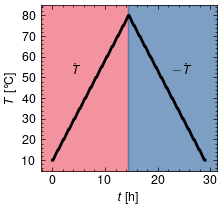

In [2]:
import re
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import scienceplots

plt.style.use(['science', 'nature', 'bright'])

# ---------------- Files ----------------
heating_files = [
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_10.csv',  # maybe missing
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_15.csv',
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_20.csv',
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_25.csv',
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_30.csv',
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_35.csv',
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_40.csv',
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_45.csv',
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_50.csv',
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_55.csv',
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_60.csv',
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_65.csv',
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_70.csv',
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_75.csv',
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_80.csv'
]

cooling_files = [
    '../data/processed/mc_1.50/cooling/mc_1.50_cooling_FS_10.csv',
    '../data/processed/mc_1.50/cooling/mc_1.50_cooling_FS_15.csv',
    '../data/processed/mc_1.50/cooling/mc_1.50_cooling_FS_20.csv',
    '../data/processed/mc_1.50/cooling/mc_1.50_cooling_FS_25.csv',
    '../data/processed/mc_1.50/cooling/mc_1.50_cooling_FS_30.csv',
    '../data/processed/mc_1.50/cooling/mc_1.50_cooling_FS_35.csv',
    '../data/processed/mc_1.50/cooling/mc_1.50_cooling_FS_40.csv',
    '../data/processed/mc_1.50/cooling/mc_1.50_cooling_FS_45.csv',
    '../data/processed/mc_1.50/cooling/mc_1.50_cooling_FS_50.csv',
    '../data/processed/mc_1.50/cooling/mc_1.50_cooling_FS_55.csv',
    '../data/processed/mc_1.50/cooling/mc_1.50_cooling_FS_60.csv',
    '../data/processed/mc_1.50/cooling/mc_1.50_cooling_FS_65.csv',
    '../data/processed/mc_1.50/cooling/mc_1.50_cooling_FS_70.csv',
    '../data/processed/mc_1.50/cooling/mc_1.50_cooling_FS_75.csv'
]

# ---------------- Helper ----------------
def fs_value(path):
    m = re.search(r'FS_(\d+)', path)
    return int(m.group(1)) if m else -1

def load_file(filename):
    return pd.read_csv(filename, skiprows=[1], delimiter=',', decimal=".", encoding='utf-8')

def to_numeric_with_commas(s):
    return pd.to_numeric(
        s.astype(str)
         .str.replace(',', '.', regex=False)
         .str.replace(r'\s', '', regex=True),
        errors='coerce'
    )

# ---------------- Filter and sort ----------------
heating_files = [f for f in heating_files if Path(f).exists()]
cooling_files = [f for f in cooling_files if Path(f).exists()]

heating_files = sorted(heating_files, key=fs_value)
cooling_files = sorted(cooling_files, key=fs_value, reverse=True)

# ---------------- Load data ----------------
ordered_files = heating_files + cooling_files
dfs = [load_file(f) for f in ordered_files]
df_all = pd.concat(dfs, ignore_index=True)

time_col = 'Test Time'  # Adjust if column name differs
df_all[time_col] = to_numeric_with_commas(df_all[time_col])
df_all['Temperature'] = to_numeric_with_commas(df_all['Temperature'])
df_all = df_all.dropna(subset=[time_col, 'Temperature']).sort_values(time_col)

# ---------------- Prepare plotting variables ----------------
t0 = df_all[time_col].iloc[0]
t_hours = (df_all[time_col] - t0) / 3600.0
T = df_all['Temperature'].to_numpy()

imax = int(np.nanargmax(T))
split_time_h = float(t_hours.iloc[imax])

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
ymin, ymax = 5, 85
xpad_left = 2.2
xpad_right = 2.2
xmax = float(t_hours.iloc[-1]) + xpad_right

# ---------------- Plot ----------------
plt.figure(figsize=(2.33, 2.2))
plt.fill_betweenx([ymin, ymax], -xpad_left, split_time_h, color=colors[1], alpha=0.7)
plt.fill_betweenx([ymin, ymax], split_time_h, xmax, color=colors[0], alpha=0.7)
plt.plot(t_hours, T, '-', color='k', lw=2)

plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.xlabel("$t$ [h]", fontsize=9)
plt.ylabel("$T$ [°C]", fontsize=9)
plt.text(0.20, 0.60, r"$\dot{T}$", transform=plt.gca().transAxes, fontsize=9, ha='center', va='center')
plt.text(0.80, 0.60, r"$-\dot{T}$", transform=plt.gca().transAxes, fontsize=9, ha='center', va='center')

plt.xlim(-xpad_left, min(37, xmax))
plt.ylim(ymin, ymax)
plt.tight_layout()

# ---------------- Save figure safely ----------------
out_dir = "../figures/main/heating_cooling_protocol"
os.makedirs(out_dir, exist_ok=True)
#out_file = os.path.join(out_dir, "fig_results_heatramp_protocol_from_data.pdf")
#plt.savefig(out_file, dpi=1200, bbox_inches='tight', pad_inches=0.1)
plt.show()


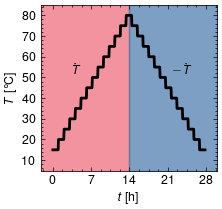

In [3]:
import re
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import scienceplots

plt.style.use(['science', 'nature', 'bright'])

# ---------------- File lists ----------------
heating_files = [f'../data/processed/mc_1.50/heating/mc_1.50_heating_FS_{i}.csv' for i in range(10, 85, 5)]
cooling_files = [f'../data/processed/mc_1.50/cooling/mc_1.50_cooling_FS_{i}.csv' for i in range(75, 5, -5)]

def fs_value(path):
    m = re.search(r'FS_(\d+)', path)
    return int(m.group(1)) if m else -1

# Keep only existing files
heating_files = [f for f in heating_files if Path(f).exists()]
cooling_files = [f for f in cooling_files if Path(f).exists()]

# Remove 10 °C files if present
heating_files = [f for f in heating_files if fs_value(f) != 10]
cooling_files = [f for f in cooling_files if fs_value(f) != 10]

# Sort properly
heating_files = sorted(heating_files, key=fs_value)
cooling_files = sorted(cooling_files, key=fs_value, reverse=True)

# ---------------- Load CSVs ----------------
def load_file_with_extra_row(filename, time_shift=0):
    df = pd.read_csv(filename, skiprows=[1], delimiter=',', decimal=".", encoding='utf-8')

    # Convert numeric
    for col in ['Test Time', 'Temperature']:
        df[col] = pd.to_numeric(
            df[col].astype(str)
                .str.replace(',', '.', regex=False)
                .str.replace(r'\s', '', regex=True),
            errors='coerce'
        )

    df = df.dropna(subset=['Test Time', 'Temperature'])

    # Apply global time shift
    df['Test Time'] = df['Test Time'] - time_shift

    # Add extra row at the beginning (Test Time - 3000 s)
    first_row = df.iloc[0].copy()
    extra_row = first_row.copy()
    extra_row['Test Time'] = first_row['Test Time'] - 3000
    df = pd.concat([pd.DataFrame([extra_row]), df], ignore_index=True)
    return df

# Apply time shift
time_shift = 3935
ordered_files = heating_files + cooling_files
dfs = [load_file_with_extra_row(f, time_shift=time_shift) for f in ordered_files]
df_all = pd.concat(dfs, ignore_index=True)

# ---------------- Prepare plot ----------------
df_all = df_all.sort_values('Test Time')
t_hours = (df_all['Test Time'] - df_all['Test Time'].iloc[0]) / 3600.0
T = df_all['Temperature'].to_numpy()

# Split heating/cooling
imax = int(np.nanargmax(T))
split_time_h = 13.90

# Plot ranges
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
ymin, ymax = 5, 85
xpad_left, xpad_right = 2.2, 2.2
xmax = float(t_hours.iloc[-1]) + xpad_right
x_min, x_max = -xpad_left, min(37, xmax)

# X-axis ticks (5 intervals)
x_ticks = np.linspace(0, 35, 6)

plt.figure(figsize=(2.33, 2.2))
plt.fill_betweenx([ymin, ymax], -xpad_left, split_time_h, color=colors[1], alpha=0.7)
plt.fill_betweenx([ymin, ymax], split_time_h, xmax, color=colors[0], alpha=0.7)
plt.plot(t_hours, T, '-', color='k', lw=2)

plt.xticks(x_ticks, [f"{x:.0f}" for x in x_ticks], fontsize=9)
plt.yticks(fontsize=9)
plt.xlabel("$t$ [h]", fontsize=9)
plt.ylabel("$T$ [°C]", fontsize=9)
plt.text(0.20, 0.60, r"$\dot{T}$", transform=plt.gca().transAxes, fontsize=9, ha='center', va='center')
plt.text(0.80, 0.60, r"$-\dot{T}$", transform=plt.gca().transAxes, fontsize=9, ha='center', va='center')

plt.xlim(x_min, x_max)
plt.ylim(ymin, ymax)
plt.tight_layout()

# ---------------- Save figure ----------------
out_dir = "../figures/main/heating_cooling_protocol"
os.makedirs(out_dir, exist_ok=True)
out_file = os.path.join(out_dir, "fig_results_heatramp_protocol_from_data.pdf")
plt.savefig(out_file, dpi=1200, bbox_inches='tight', pad_inches=0.1)

plt.show()


In [4]:
final_time_s = df_all['Test Time'].iloc[-1]
final_time_h = final_time_s / 3600.0

print(f"Final Test Time: {final_time_s:.0f} s ({final_time_h:.2f} h)")


Final Test Time: 100065 s (27.80 h)


In [5]:
# Print start times for each experiment in hours
print("Start times of each experiment (hours):")
for f, df in zip(ordered_files, dfs):
    # The first "real" row after the extra added row
    start_time_s = df['Test Time'].iloc[1]  # iloc[0] is the extra row
    start_time_h = start_time_s / 3600.0
    print(f"{Path(f).name}: {start_time_h:.3f} h")


Start times of each experiment (hours):
mc_1.50_heating_FS_15.csv: 0.833 h
mc_1.50_heating_FS_20.csv: 1.865 h
mc_1.50_heating_FS_25.csv: 2.896 h
mc_1.50_heating_FS_30.csv: 3.929 h
mc_1.50_heating_FS_35.csv: 4.960 h
mc_1.50_heating_FS_40.csv: 5.993 h
mc_1.50_heating_FS_45.csv: 7.024 h
mc_1.50_heating_FS_50.csv: 8.054 h
mc_1.50_heating_FS_55.csv: 9.088 h
mc_1.50_heating_FS_60.csv: 10.118 h
mc_1.50_heating_FS_65.csv: 11.151 h
mc_1.50_heating_FS_70.csv: 12.182 h
mc_1.50_heating_FS_75.csv: 13.213 h
mc_1.50_heating_FS_80.csv: 14.246 h
mc_1.50_cooling_FS_75.csv: 15.276 h
mc_1.50_cooling_FS_70.csv: 16.307 h
mc_1.50_cooling_FS_65.csv: 17.340 h
mc_1.50_cooling_FS_60.csv: 18.371 h
mc_1.50_cooling_FS_55.csv: 19.404 h
mc_1.50_cooling_FS_50.csv: 20.435 h
mc_1.50_cooling_FS_45.csv: 21.468 h
mc_1.50_cooling_FS_40.csv: 22.499 h
mc_1.50_cooling_FS_35.csv: 23.529 h
mc_1.50_cooling_FS_30.csv: 24.562 h
mc_1.50_cooling_FS_25.csv: 25.593 h
mc_1.50_cooling_FS_20.csv: 26.626 h
mc_1.50_cooling_FS_15.csv: 27.657

In [ ]:
import re
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'nature', 'bright'])

heating_files = [
    #'../data/processed/mc_1.50/heating/mc_1.50_heating_FS_10.csv',  # maybe missing
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_15.csv',
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_20.csv',
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_25.csv',
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_30.csv',
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_35.csv',
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_40.csv',
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_45.csv',
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_50.csv',
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_55.csv',
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_60.csv',
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_65.csv',
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_70.csv',
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_75.csv',
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_80.csv'
]

cooling_files = [
    #'../data/processed/mc_1.50/cooling/mc_1.50_cooling_FS_10.csv',
    '../data/processed/mc_1.50/cooling/mc_1.50_cooling_FS_15.csv',
    '../data/processed/mc_1.50/cooling/mc_1.50_cooling_FS_20.csv',
    '../data/processed/mc_1.50/cooling/mc_1.50_cooling_FS_25.csv',
    '../data/processed/mc_1.50/cooling/mc_1.50_cooling_FS_30.csv',
    '../data/processed/mc_1.50/cooling/mc_1.50_cooling_FS_35.csv',
    '../data/processed/mc_1.50/cooling/mc_1.50_cooling_FS_40.csv',
    '../data/processed/mc_1.50/cooling/mc_1.50_cooling_FS_45.csv',
    '../data/processed/mc_1.50/cooling/mc_1.50_cooling_FS_50.csv',
    '../data/processed/mc_1.50/cooling/mc_1.50_cooling_FS_55.csv',
    '../data/processed/mc_1.50/cooling/mc_1.50_cooling_FS_60.csv',
    '../data/processed/mc_1.50/cooling/mc_1.50_cooling_FS_65.csv',
    '../data/processed/mc_1.50/cooling/mc_1.50_cooling_FS_70.csv',
    '../data/processed/mc_1.50/cooling/mc_1.50_cooling_FS_75.csv'
]

def fs_value(path):
    m = re.search(r'FS_(\d+)', path)
    return int(m.group(1)) if m else -1

# Keep only existing files
heating_files = [f for f in heating_files if Path(f).exists()]
cooling_files = [f for f in cooling_files if Path(f).exists()]

# Order: heating asc (10→80), cooling desc (75→10)
heating_files = sorted(heating_files, key=fs_value)
cooling_files = sorted(cooling_files, key=fs_value, reverse=True)

def load_first_point(filename):
    df = pd.read_csv(filename, skiprows=[1], delimiter=',', decimal=".", encoding='utf-8')
    return df.iloc[0]

ordered_files = heating_files + cooling_files
first_points = [load_first_point(f) for f in ordered_files]

def convert_to_numeric(value):
    """Convert a single value to a numeric type, handling commas and spaces."""
    # replace commas with dots and remove spaces, then convert to float
    try:
        return pd.to_numeric(value.replace(',', '.').replace(' ', ''), errors='coerce')
    except AttributeError:
        return pd.to_numeric(value, errors='coerce')

# Extract and convert time data to numeric
time_points = [convert_to_numeric(p['Test Time']) for p in first_points]  # Assuming 'Test Time' is the column
storage_modulus = [convert_to_numeric(p['Storage Modulus']) for p in first_points]  # Replace with actual column name
loss_modulus = [convert_to_numeric(p['Loss Modulus']) for p in first_points]  # Replace with actual column name

# Convert time to hours if necessary
t0 = time_points[0]
time_hours = [(t - t0) / 3600.0 for t in time_points]

# Create the plot
plt.figure(figsize=(2.33, 2.2))

# Define colors
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Shade the left side red and the right side blue
split_time_h = 13.90#float(time_hours[len(heating_files)-1])  # Adjust split point based on heating data count
plt.fill_betweenx([-1, 5e4], -xpad_left, split_time_h, color=colors[1], alpha=0.7)
plt.fill_betweenx([-1, 5e4], split_time_h, xmax, color=colors[0], alpha=0.7)

# Plotting the data in log scale
plt.plot(time_hours, storage_modulus, "o", markersize=5, color="k", linestyle="none", markevery=1, label='Storage Modulus')
plt.plot(time_hours, loss_modulus, "o", markersize=5, color="k", linestyle="none", fillstyle="none", markevery=1, label='Loss Modulus')
x_ticks = np.linspace(0, 35, 6)

# Determine min and max for x-axis
# Set x and y limits
plt.xticks(x_ticks, [f"{x:.0f}" for x in x_ticks], fontsize=9)
plt.yticks(fontsize=9)
plt.yscale('log')
plt.xlim(x_min, x_max)
plt.ylim(0.05, 20000)
plt.xlabel("$t$ [h]", fontsize=9)
plt.ylabel('$G^{\prime}(\omega_0,T), G^{\prime \prime}(\omega_0,T)~\mathrm{[Pa]}$', fontsize=9)

# Add text
text = f"$\\omega_0 = 0.03~\\rm{{rad~s}}^{{-1}}$"
plt.text(0.5, 0.085, text, horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=9)

# Legend
#plt.legend(fontsize=12)

# Adjust layout and save the figure
plt.tight_layout()
out_dir = "../figures/main/heating_cooling_protocol"
os.makedirs(out_dir, exist_ok=True)
out_file = os.path.join(out_dir, "fig_results_evolution_over_time_0_03rad.pdf")
plt.savefig(out_file, dpi=1200, bbox_inches='tight', pad_inches=0.1)
plt.show()


In [ ]:
import re
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
from matplotlib.ticker import LogLocator


# Apply the plot style
plt.style.use(['science', 'nature', 'bright'])

# Specify file paths for heating at 20 and 80
files_20_80 = [
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_15.csv',
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_80.csv'
]

# Verify the existence of the files
files_20_80 = [f for f in files_20_80 if Path(f).exists()]

# Load function for extracting the necessary data
def load_data(filename):
    df = pd.read_csv(filename, skiprows=[1], delimiter=',', decimal=".", encoding='utf-8')
    return df[['Angular Frequency', 'Storage Modulus', 'Loss Modulus']]

# Prepare data for plotting
data_20_80 = [load_data(f) for f in files_20_80]

# Initialize the plot
plt.figure(figsize=(2.33, 2.2))  # Applying custom figure size from previous example

# Define colors for distinction. Stay consistent with idx order
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Plot data for heating at 20 and 80, but swap legend order
handles = []  # To manually manage handle order

for idx, data in enumerate(data_20_80):
    angular_freq = data['Angular Frequency']
    storage_modulus = pd.to_numeric(data['Storage Modulus'], errors='coerce')
    loss_modulus = pd.to_numeric(data['Loss Modulus'], errors='coerce')

    # Update labels for temperature indication
    temperature = [15, 80][idx]
    label_storage = f'$T={temperature}^\circ$C'

    # Plot Storage and Loss Modulus with updated marker styles
    h1, = plt.plot(angular_freq, storage_modulus, 'o', color=colors[idx], markersize=5, label=label_storage)
    plt.plot(angular_freq, loss_modulus, 'o', color=colors[idx], markersize=5, fillstyle="none")

    # Keep track of handles to reorder later
    handles.append(h1)

# Reorder handles to swap temperature order for legend
handles = [handles[1], handles[0]]  # This swaps the order

# Set axes labels and update title
plt.xlabel('$\omega~\mathrm{[rad~s^{-1}]}$', fontsize=9)
plt.ylabel('$G^{\prime}(\omega), G^{\prime \prime}(\omega)$ [Pa]', fontsize=9)

# Update ticks and grid for aesthetic coherence
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.tick_params(axis='y', which='both', direction='in', labelsize=9)
plt.tick_params(axis='x', which='both', direction='in', labelsize=9)
plt.xscale('log')
plt.yscale('log')

# Force major ticks at each decade
plt.gca().xaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
plt.gca().yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))

# Force minor ticks between decades (2, 3, ..., 9)
plt.gca().xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=100))
plt.gca().yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=100))

plt.xlim(0.01, 3)
plt.ylim(0.05, 20000)

# Apply updated legend aesthetics with reordered handles
plt.legend(handles=handles, fontsize=8, ncol=1, columnspacing=0.1, handletextpad=0.1, frameon=False, loc='lower right')

# Adjust layout and show the plot
plt.tight_layout()
out_dir = "../figures/main/heating_cooling_protocol"
os.makedirs(out_dir, exist_ok=True)
out_file = os.path.join(out_dir, "fig_storage_loss_vs_freq_20_80.pdf")
plt.savefig(out_file, dpi=1200, bbox_inches='tight', pad_inches=0.1)
plt.show()

In [ ]:
import re
from pathlib import Path
import pandas as pd
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import scienceplots
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from matplotlib.ticker import MaxNLocator, MultipleLocator

# Provide your file lists here
heating_files = [
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_10.csv',  # maybe missing
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_15.csv',
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_20.csv',
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_25.csv',
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_30.csv',
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_35.csv',
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_40.csv',
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_45.csv',
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_50.csv',
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_55.csv',
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_60.csv',
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_65.csv',
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_70.csv',
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_75.csv',
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_80.csv'
]

cooling_files = [
    '../data/processed/mc_1.50/heating/mc_1.50_heating_FS_80.csv',
    '../data/processed/mc_1.50/cooling/mc_1.50_cooling_FS_75.csv',
    '../data/processed/mc_1.50/cooling/mc_1.50_cooling_FS_70.csv',
    '../data/processed/mc_1.50/cooling/mc_1.50_cooling_FS_65.csv',
    '../data/processed/mc_1.50/cooling/mc_1.50_cooling_FS_60.csv',
    '../data/processed/mc_1.50/cooling/mc_1.50_cooling_FS_55.csv',
    '../data/processed/mc_1.50/cooling/mc_1.50_cooling_FS_50.csv',
    '../data/processed/mc_1.50/cooling/mc_1.50_cooling_FS_45.csv',
    '../data/processed/mc_1.50/cooling/mc_1.50_cooling_FS_40.csv',
    '../data/processed/mc_1.50/cooling/mc_1.50_cooling_FS_35.csv',
    '../data/processed/mc_1.50/cooling/mc_1.50_cooling_FS_30.csv',
    '../data/processed/mc_1.50/cooling/mc_1.50_cooling_FS_25.csv',
    '../data/processed/mc_1.50/cooling/mc_1.50_cooling_FS_20.csv',
    '../data/processed/mc_1.50/cooling/mc_1.50_cooling_FS_15.csv',
    '../data/processed/mc_1.50/cooling/mc_1.50_cooling_FS_10.csv'

]



plt.style.use(['science', 'nature', 'bright'])

# Verify the existence of the files
heating_files = [f for f in heating_files if Path(f).exists()]
cooling_files = [f for f in cooling_files if Path(f).exists()]

# Load data function
def load_data(filename):
    df = pd.read_csv(filename, skiprows=[1], delimiter=',', decimal=".", encoding='utf-8')
    df['Angular Frequency'] = np.log10(df['Angular Frequency'])
    return df[['Angular Frequency', 'Temperature', 'Storage Modulus', 'Loss Modulus']]

data_heating = pd.concat([load_data(f) for f in heating_files], ignore_index=True)
data_cooling = pd.concat([load_data(f) for f in cooling_files], ignore_index=True)

# Adjust temperatures for fitting
X_heating = data_heating[['Angular Frequency', 'Temperature']].copy()
X_heating['Temperature'] /= 10
y_heating_storage = np.log(pd.to_numeric(data_heating['Storage Modulus'], errors='coerce'))
y_heating_loss = np.log(pd.to_numeric(data_heating['Loss Modulus'], errors='coerce'))

X_cooling = data_cooling[['Angular Frequency', 'Temperature']].copy()
X_cooling['Temperature'] /= 10
y_cooling_storage = np.log(pd.to_numeric(data_cooling['Storage Modulus'], errors='coerce'))
y_cooling_loss = np.log(pd.to_numeric(data_cooling['Loss Modulus'], errors='coerce'))

# Fit Gaussian Process Regression models
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-0, 1e2))
gpr_heating_storage = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
gpr_heating_storage.fit(X_heating, y_heating_storage)

gpr_cooling_storage = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
gpr_cooling_storage.fit(X_cooling, y_cooling_storage)

gpr_heating_loss = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
gpr_heating_loss.fit(X_heating, y_heating_loss)

gpr_cooling_loss = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
gpr_cooling_loss.fit(X_cooling, y_cooling_loss)

# Prediction grid setup
freq_range_log = np.linspace(np.min(X_heating['Angular Frequency']), np.max(X_heating['Angular Frequency']), 100)
temp_range_adjusted = np.linspace(1, 8, 100)
X_pred = np.array([[f, t] for t in temp_range_adjusted for f in freq_range_log])

storage_preds_heating, _ = gpr_heating_storage.predict(X_pred, return_std=True)
loss_preds_heating, _ = gpr_heating_loss.predict(X_pred, return_std=True)
storage_preds_cooling, _ = gpr_cooling_storage.predict(X_pred, return_std=True)
loss_preds_cooling, _ = gpr_cooling_loss.predict(X_pred, return_std=True)

# Reshape for plot surfaces
F, T_adjusted = np.meshgrid(freq_range_log, temp_range_adjusted)
T_normal = T_adjusted * 10



In [ ]:
# Plot for Storage Modulus
fig = plt.figure(figsize=(3.640625, 2.2))
ax = fig.add_subplot(111, projection='3d')

ax.set_position([0, 0, 1, 1])

ax.plot_surface(F, T_normal, storage_preds_heating.reshape(100, 100), color=colors[1], linewidth=0, alpha=0.6)
ax.plot_surface(F, T_normal, storage_preds_cooling.reshape(100, 100), color=colors[0], linewidth=0, alpha=0.6)

ax.scatter(data_heating['Angular Frequency'], data_heating['Temperature'], 
           y_heating_storage, c=colors[1], s=30, edgecolors='none', linewidth=0.4, label='heating', depthshade=False, alpha=0.7)

ax.scatter(data_cooling['Angular Frequency'], data_cooling['Temperature'], 
           y_cooling_storage, edgecolors=colors[0], facecolors='none', s=30, linewidth=0.4, label='cooling', depthshade=False)

ax.set_box_aspect([1, 1, 0.95])  # e.g., [1, 1, 0.8] to compress z relative to x and y


ax.set_xlabel(r'$\log~\omega$ [rad~s$^{-1}$]', labelpad=2, fontsize=9)
ax.set_ylabel(r'$T$ [$^{\circ}$C]', labelpad=0, fontsize=9)
# Remove built-in z-label 
ax.set_zlabel("") 
# Manually add flipped label (bottom to top) 
ax.text2D(-0.08, 0.5, r"$\log~G^{\prime}$ [Pa]", fontsize=9, rotation=90, # ← rotates bottom-to-top 
          va='center', ha='center', transform=ax.transAxes)

ax.xaxis.set_major_locator(MaxNLocator(3))
ax.yaxis.set_major_locator(MaxNLocator(4))
ax.zaxis.set_major_locator(MaxNLocator(5))

# Turning off minor ticks
ax.xaxis.set_minor_locator(MultipleLocator(0.3))
ax.yaxis.set_minor_locator(MultipleLocator(10))
ax.zaxis.set_minor_locator(MultipleLocator(0.4))

ax.tick_params(which='major', length=2, pad=0, labelsize=9)

ax.view_init(17, 210)
ax.legend(loc='upper left', frameon=False, ncols=1, fontsize=8)

ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.4)

#plt.tight_layout()
out_dir = "../figures/main/heating_cooling_protocol"
os.makedirs(out_dir, exist_ok=True)
out_file = os.path.join(out_dir, "fig_results_storage_modulus_3d.pdf")
plt.savefig(out_file, dpi=1200, 
            bbox_inches='tight', 
            pad_inches=0.3)
plt.show()

In [ ]:
# Plot for Storage Modulus
fig = plt.figure(figsize=(3.640625, 2.2))
ax = fig.add_subplot(111, projection='3d')

ax.set_position([0, 0, 1, 1])

ax.plot_surface(F, T_normal, loss_preds_heating.reshape(100, 100), color=colors[1], linewidth=0, alpha=0.6)
ax.plot_surface(F, T_normal, loss_preds_cooling.reshape(100, 100), color=colors[0], linewidth=0, alpha=0.6)

ax.scatter(data_heating['Angular Frequency'], data_heating['Temperature'], 
           y_heating_loss, c=colors[1], s=30, edgecolors='none', linewidth=0.4, label='heating', depthshade=False, alpha=0.7)

ax.scatter(data_cooling['Angular Frequency'], data_cooling['Temperature'], 
           y_cooling_loss, edgecolors=colors[0], facecolors='none', s=30, linewidth=0.4, label='cooling', depthshade=False)

ax.set_box_aspect([1, 1, 0.95])  # e.g., [1, 1, 0.8] to compress z relative to x and y


ax.set_xlabel(r'$\log~\omega$ [rad~s$^{-1}$]', labelpad=2, fontsize=9)
ax.set_ylabel(r'$T$ [$^{\circ}$C]', labelpad=0, fontsize=9)
#ax.set_zlabel(r"$\log~G^{\prime\prime}$ [Pa]", labelpad=0, fontsize=14)
# Remove built-in z-label 
ax.set_zlabel("") 
# Manually add flipped label (bottom to top) 
ax.text2D(-0.08, 0.5, r"$\log~G^{\prime \prime}$ [Pa]", fontsize=9, rotation=90, # ← rotates bottom-to-top 
          va='center', ha='center', transform=ax.transAxes)

ax.xaxis.set_major_locator(MaxNLocator(3))
ax.yaxis.set_major_locator(MaxNLocator(4))
ax.zaxis.set_major_locator(MaxNLocator(5))

# Turning off minor ticks
ax.xaxis.set_minor_locator(MultipleLocator(0.3))
ax.yaxis.set_minor_locator(MultipleLocator(10))
ax.zaxis.set_minor_locator(MultipleLocator(0.25))

ax.tick_params(which='major', length=2, pad=0, labelsize=9)

ax.view_init(17, 210)
#ax.legend(loc='upper left', frameon=False, ncols=1, fontsize=10)

ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.4)

out_dir = "../figures/main/heating_cooling_protocol"
os.makedirs(out_dir, exist_ok=True)
out_file = os.path.join(out_dir, "fig_results_loss_modulus_3d.pdf")
plt.savefig(out_file, dpi=1200, 
            bbox_inches='tight', 
            pad_inches=0.3)
plt.show()

In [ ]:
# Plot for Storage Modulus
fig = plt.figure(figsize=(3.640625, 2.2))
ax = fig.add_subplot(111, projection='3d')

ax.set_position([0, 0, 1, 1])
tan_delta_preds_heating = np.exp(loss_preds_heating) / np.exp(storage_preds_heating)
tan_delta_preds_cooling = np.exp(loss_preds_cooling) / np.exp(storage_preds_cooling)



ax.plot_surface(F, T_normal, tan_delta_preds_heating.reshape(100, 100), color=colors[1], linewidth=0, alpha=0.6)
ax.plot_surface(F, T_normal, tan_delta_preds_cooling.reshape(100, 100), color=colors[0], linewidth=0, alpha=0.6)

#ax.scatter(data_heating['Angular Frequency'], data_heating['Temperature'], 
           #y_heating_storage, c=colors[1], s=30, edgecolors='none', linewidth=0.4, label='heating', depthshade=False, alpha=0.7)

#ax.scatter(data_cooling['Angular Frequency'], data_cooling['Temperature'], 
           #y_cooling_storage, edgecolors=colors[0], facecolors='none', s=30, linewidth=0.4, label='cooling', depthshade=False)

ax.set_box_aspect([1, 1, 0.95])  # e.g., [1, 1, 0.8] to compress z relative to x and y


ax.set_xlabel(r'$\log~\omega$ [rad~s$^{-1}$]', labelpad=2, fontsize=9)
ax.set_ylabel(r'$T$ [$^{\circ}$C]', labelpad=0, fontsize=9)
# Remove built-in z-label 
ax.set_zlabel("") 
# Manually add flipped label (bottom to top) 
ax.text2D(-0.08, 0.5, r"$\log~G^{\prime}$ [Pa]", fontsize=9, rotation=90, # ← rotates bottom-to-top 
          va='center', ha='center', transform=ax.transAxes)
ax.set_zscale('log')
ax.set_zlim(1e-1, 1e0)
#ax.xaxis.set_major_locator(MaxNLocator(3))
#ax.yaxis.set_major_locator(MaxNLocator(4))
#ax.zaxis.set_major_locator(MaxNLocator(5))

# Turning off minor ticks
#ax.xaxis.set_minor_locator(MultipleLocator(0.3))
#ax.yaxis.set_minor_locator(MultipleLocator(10))
#ax.zaxis.set_minor_locator(MultipleLocator(0.4))

ax.tick_params(which='major', length=2, pad=0, labelsize=9)

ax.view_init(17, 210)
ax.legend(loc='upper left', frameon=False, ncols=1, fontsize=8)

ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.4)

#plt.tight_layout()
#plt.savefig('fig_results_tand_delta_3d.pdf', dpi=1200, 
#            bbox_inches='tight', 
#            pad_inches=0.3)
plt.show()

# Reshape tan delta predictions
tan_delta_preds_heating_grid = tan_delta_preds_heating.reshape(F.shape)
tan_delta_preds_cooling_grid = tan_delta_preds_cooling.reshape(F.shape)

# Compute variance along frequency (columns) for each temperature
var_tan_delta_preds_heating = np.var(tan_delta_preds_heating_grid, axis=1)
var_tan_delta_preds_cooling = np.var(tan_delta_preds_cooling_grid, axis=1)

# Find index of minimum variance
idx_min_var_preds_heating = np.argmin(var_tan_delta_preds_heating)
idx_min_var_preds_cooling = np.argmin(var_tan_delta_preds_cooling)

# Corresponding temperature (first column of T_normal)
T_indep_preds_heating = T_normal[idx_min_var_preds_heating, 0]
T_indep_preds_cooling = T_normal[idx_min_var_preds_cooling, 0]

print(f"Heating: tan δ independent of frequency at T ≈ {T_indep_preds_heating:.2f} °C")
print(f"Cooling: tan δ independent of frequency at T ≈ {T_indep_preds_cooling:.2f} °C")


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Reshape GP predictions to 2D grids (n_temp x n_freq) ---
storage_heating_grid = np.exp(storage_preds_heating.reshape(F.shape))
loss_heating_grid = np.exp(loss_preds_heating.reshape(F.shape))
tan_delta_heating_grid = loss_heating_grid / storage_heating_grid

storage_cooling_grid = np.exp(storage_preds_cooling.reshape(F.shape))
loss_cooling_grid = np.exp(loss_preds_cooling.reshape(F.shape))
tan_delta_cooling_grid = loss_cooling_grid / storage_cooling_grid

# --- Original experimental data ---
T_heating = data_heating['Temperature'].values
freq_heating = 10**data_heating['Angular Frequency'].values
Gp_heating = pd.to_numeric(data_heating['Storage Modulus'], errors='coerce').values
Gpp_heating = pd.to_numeric(data_heating['Loss Modulus'], errors='coerce').values
tan_delta_heating = Gpp_heating / Gp_heating

T_cooling = data_cooling['Temperature'].values
freq_cooling = 10**data_cooling['Angular Frequency'].values
Gp_cooling = pd.to_numeric(data_cooling['Storage Modulus'], errors='coerce').values
Gpp_cooling = pd.to_numeric(data_cooling['Loss Modulus'], errors='coerce').values
tan_delta_cooling = Gpp_cooling / Gp_cooling

# --- Tan delta grids: n_temp x n_freq ---
# heating: tan_delta_heating_grid, cooling: tan_delta_cooling_grid

# Function to find temperature where variance across frequencies is minimal within a range
def find_freq_indep_temp(T_array, tan_delta_grid, Tmin, Tmax):
    mask_range = (T_array[:,0] >= Tmin) & (T_array[:,0] <= Tmax)
    var_along_freq = np.var(tan_delta_grid[mask_range, :], axis=1)
    idx_min = np.argmin(var_along_freq)
    T_indep = T_array[mask_range,0][idx_min]
    return T_indep

T_indep_heating = find_freq_indep_temp(T_normal, tan_delta_heating_grid, 38, 50)
T_indep_cooling = find_freq_indep_temp(T_normal, tan_delta_cooling_grid, 20, 28)

print(f"Heating: tan δ frequency-independent at T ≈ {T_indep_heating:.2f} °C")
print(f"Cooling: tan δ frequency-independent at T ≈ {T_indep_cooling:.2f} °C")


# --- Original experimental frequencies ---
orig_freqs = np.array([0.03, 0.0426, 0.0605, 0.0859, 0.122, 0.173, 0.246, 0.349, 0.496, 0.704, 1.0])

# --- Find closest indices in GP prediction grid (scaled frequencies) ---
# The prediction grid F is already in log10 if from earlier code
# Correct scaled indices
log_orig_freqs = np.log10(orig_freqs)  # convert to log10
freq_indices = [np.argmin(np.abs(F[0,:] - f)) for f in log_orig_freqs]
# --- Colors ---
colors = plt.cm.tab20c(np.linspace(0, 1, len(orig_freqs)))
colors_bright = plt.rcParams['axes.prop_cycle'].by_key()['color']

# --- Plot Storage Modulus ---
plt.figure(figsize=(2.33, 2.2))
for i, f_val in enumerate(orig_freqs):
    # Heating data
    mask_h = np.isclose(freq_heating, f_val, atol=1e-5)
    plt.scatter(T_heating[mask_h], Gp_heating[mask_h], s=20, color=colors[i], label=f"$\omega={f_val:.2f}$")
    # Cooling data
    mask_c = np.isclose(freq_cooling, f_val, atol=1e-5)
    plt.scatter(T_cooling[mask_c], Gp_cooling[mask_c], s=20, facecolors='none', edgecolors=colors[i])
    # Predictions
    plt.plot(T_normal[:,0], storage_heating_grid[:, freq_indices[i]], '-', lw=1.5, color=colors[i], alpha=0.6)
    plt.plot(T_normal[:,0], storage_cooling_grid[:, freq_indices[i]], '--', lw=1.5, color=colors[i], alpha=0.6)

plt.xlabel("$T$ [$^{\circ}$C]", fontsize=9)
plt.ylabel("$G^{\prime}(\omega,T)$ [Pa]", fontsize=9)
plt.yscale('log')
plt.xlim(0,90)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(
    handles[::-1], labels[::-1],  # reverse order of legend items
    title='$\omega~[{\\rm rad~s}^{-1}]$',  # properly formatted LaTeX title
    fontsize=5,
    ncol=1,
    frameon=True,
    facecolor='white',
    edgecolor='none'
)
plt.tight_layout()
out_dir = "../figures/main/heating_cooling_protocol"
os.makedirs(out_dir, exist_ok=True)
out_file = os.path.join(out_dir, "storage_modulus_1.5_surface_2d.pdf")
plt.savefig(out_file, dpi=1200, 
            bbox_inches='tight')
plt.show()

# --- Plot Loss Modulus ---
plt.figure(figsize=(2.33, 2.2))
for i, f_val in enumerate(orig_freqs):
    mask_h = np.isclose(freq_heating, f_val, atol=1e-5)
    mask_c = np.isclose(freq_cooling, f_val, atol=1e-5)
    plt.scatter(T_heating[mask_h], Gpp_heating[mask_h], s=20, color=colors[i], label=f"$\omega$={f_val} (H)")
    plt.scatter(T_cooling[mask_c], Gpp_cooling[mask_c], s=20, facecolors='none', edgecolors=colors[i],)
    plt.plot(T_normal[:,0], loss_heating_grid[:, freq_indices[i]], '-', lw=1.5, color=colors[i], alpha=0.6)
    plt.plot(T_normal[:,0], loss_cooling_grid[:, freq_indices[i]], '--', lw=1.5, color=colors[i], alpha=0.6)

plt.xlabel("$T$ [$^{\circ}$C]", fontsize=9)
plt.ylabel("$G^{\prime\prime}(\omega,T)$ [Pa]", fontsize=9)
plt.yscale('log')
plt.xlim(0,90)

plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
#plt.legend(fontsize=6, ncol=2, frameon=False)
plt.tight_layout()
out_dir = "../figures/main/heating_cooling_protocol"
os.makedirs(out_dir, exist_ok=True)
out_file = os.path.join(out_dir, "loss_modulus_1.5_surface_2d.pdf")
plt.savefig(out_file, dpi=1200, 
            bbox_inches='tight')
plt.show()

# --- Plot Tan Delta ---
plt.figure(figsize=(2.33, 2.2))
for i, f_val in enumerate(orig_freqs):
    mask_h = np.isclose(freq_heating, f_val, atol=1e-5)
    mask_c = np.isclose(freq_cooling, f_val, atol=1e-5)
    plt.scatter(T_heating[mask_h], tan_delta_heating[mask_h], s=20, color=colors[i])
    plt.scatter(T_cooling[mask_c], tan_delta_cooling[mask_c], s=20, facecolors='none', edgecolors=colors[i])
    plt.plot(T_normal[:,0], tan_delta_heating_grid[:, freq_indices[i]], '-', lw=1.5, color=colors[i], alpha=0.6)
    plt.plot(T_normal[:,0], tan_delta_cooling_grid[:, freq_indices[i]], '--', lw=1.5, color=colors[i], alpha=0.6)

# Add markers for frequency-independent temperatures
#plt.axvline(T_indep_heating, color=colors_bright[1], linestyle=':', lw=1.5, label=f"T_indep (H) ≈ {T_indep_heating:.1f}°C")
#plt.axvline(T_indep_cooling, color=colors_bright[0], linestyle=':', lw=1.5, label=f"T_indep (C) ≈ {T_indep_cooling:.1f}°C")
# Solid line replacement: red upward arrow (heating)
plt.annotate('', xy=(T_indep_heating, 1.5e-2), xytext=(T_indep_heating, 5e-2),
            arrowprops=dict(arrowstyle='-|>,head_width=0.3,head_length=0.5', 
                                    color="red", lw=1.2, fill=False))
        
# Dashed line replacement: blue downward arrow (cooling)
plt.annotate('', xy=(T_indep_cooling, 8e-2), xytext=(T_indep_cooling, 2.3e-2),
            arrowprops=dict(arrowstyle='-|>,head_width=0.3,head_length=0.5', 
                            color='blue', lw=1.2))

plt.xlabel("$T$ [$^{\circ}$C]", fontsize=9)
plt.ylabel("$\\tan{\\delta}(\omega, T)$", fontsize=9)
plt.yscale('log')
plt.xlim(0,90)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
#plt.legend(fontsize=6, ncol=2, frameon=False)
plt.tight_layout()
out_dir = "../figures/main/heating_cooling_protocol"
os.makedirs(out_dir, exist_ok=True)
out_file = os.path.join(out_dir, "loss_factor_1.5_surface_2d.pdf")
plt.savefig(out_file, dpi=1200, 
            bbox_inches='tight')
plt.show()

In [ ]:
# --- Tan delta grids: n_temp x n_freq ---
# heating: tan_delta_heating_grid, cooling: tan_delta_cooling_grid

# Function to find temperature where variance across frequencies is minimal within a range
def find_freq_indep_temp(T_array, tan_delta_grid, Tmin, Tmax):
    mask_range = (T_array[:,0] >= Tmin) & (T_array[:,0] <= Tmax)
    var_along_freq = np.var(tan_delta_grid[mask_range, :], axis=1)
    idx_min = np.argmin(var_along_freq)
    T_indep = T_array[mask_range,0][idx_min]
    return T_indep

T_indep_heating = find_freq_indep_temp(T_normal, tan_delta_heating_grid, 38, 50)
T_indep_cooling = find_freq_indep_temp(T_normal, tan_delta_cooling_grid, 20, 28)

print(f"Heating: tan δ frequency-independent at T ≈ {T_indep_heating:.2f} °C")
print(f"Cooling: tan δ frequency-independent at T ≈ {T_indep_cooling:.2f} °C")


In [ ]:
# Reshape predictions to 2D (temperature x frequency)
storage_heating_2d = storage_preds_heating.reshape(len(temp_range_adjusted), len(freq_range_log))
storage_cooling_2d = storage_preds_cooling.reshape(len(temp_range_adjusted), len(freq_range_log))

# Use 1D temperature array for derivative
T_1d = temp_range_adjusted * 10  # back to normal temperature scale

# Arrays to store temperature at max derivative
T_max_deriv_heating = np.zeros(len(freq_range_log))
T_max_deriv_cooling = np.zeros(len(freq_range_log))

# Loop over frequencies (columns)
for i in range(len(freq_range_log)):
    dGdT_heating = np.gradient(storage_heating_2d[:, i], T_1d)
    dGdT_cooling = np.gradient(storage_cooling_2d[:, i], T_1d)
    
    idx_max_heating = np.argmax(dGdT_heating)
    idx_max_cooling = np.argmax(dGdT_cooling)
    
    T_max_deriv_heating[i] = T_1d[idx_max_heating]
    T_max_deriv_cooling[i] = T_1d[idx_max_cooling]

# Plot temperature of max slope vs frequency
plt.figure(figsize=(4,3))
plt.plot(freq_range_log, T_max_deriv_heating, 'o-', label='Heating')
plt.plot(freq_range_log, T_max_deriv_cooling, 's-', label='Cooling')
plt.xlabel(r'$\log~\omega$ [rad/s]')
plt.ylabel('T at max dG\'/dT [°C]')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# Assume concentration
concentration = 1.50  # or get from filename if multiple concentrations

# Create DataFrame
df_max_derivative = pd.DataFrame({
    'Concentration': [concentration] * len(freq_range_log),
    'Angular Frequency': freq_range_log,
    'Tgel': T_max_deriv_heating,  # temperature at max slope during heating
    'Tsol': T_max_deriv_cooling   # temperature at max slope during cooling
})

# Display
print(df_max_derivative.head())

# Optional: save to CSV
#df_max_derivative.to_csv('Tgel_Tsol_vs_frequency_1.50.csv', index=False)

In [ ]:
import re
from pathlib import Path
import pandas as pd
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import scienceplots
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from matplotlib.ticker import MaxNLocator, MultipleLocator

# Provide your file lists here
heating_files = [
    '../data/processed/mc_1.00/heating/mc_1.00_heating_FS_10.csv',
    '../data/processed/mc_1.00/heating/mc_1.00_heating_FS_15.csv',
    '../data/processed/mc_1.00/heating/mc_1.00_heating_FS_20.csv',
    '../data/processed/mc_1.00/heating/mc_1.00_heating_FS_25.csv',
    '../data/processed/mc_1.00/heating/mc_1.00_heating_FS_30.csv',
    '../data/processed/mc_1.00/heating/mc_1.00_heating_FS_35.csv',
    '../data/processed/mc_1.00/heating/mc_1.00_heating_FS_40.csv',
    '../data/processed/mc_1.00/heating/mc_1.00_heating_FS_45.csv',
    '../data/processed/mc_1.00/heating/mc_1.00_heating_FS_50.csv',
    '../data/processed/mc_1.00/heating/mc_1.00_heating_FS_55.csv',
    '../data/processed/mc_1.00/heating/mc_1.00_heating_FS_60.csv',
    '../data/processed/mc_1.00/heating/mc_1.00_heating_FS_65.csv',
    '../data/processed/mc_1.00/heating/mc_1.00_heating_FS_70.csv',
    '../data/processed/mc_1.00/heating/mc_1.00_heating_FS_75.csv',
    '../data/processed/mc_1.00/heating/mc_1.00_heating_FS_80.csv'
]
cooling_files = [
    '../data/processed/mc_1.00/heating/mc_1.00_heating_FS_80.csv',
    '../data/processed/mc_1.00/cooling/mc_1.00_cooling_FS_75.csv',
    '../data/processed/mc_1.00/cooling/mc_1.00_cooling_FS_70.csv',
    '../data/processed/mc_1.00/cooling/mc_1.00_cooling_FS_65.csv',
    '../data/processed/mc_1.00/cooling/mc_1.00_cooling_FS_60.csv',
    '../data/processed/mc_1.00/cooling/mc_1.00_cooling_FS_55.csv',
    '../data/processed/mc_1.00/cooling/mc_1.00_cooling_FS_50.csv',
    '../data/processed/mc_1.00/cooling/mc_1.00_cooling_FS_45.csv',
    '../data/processed/mc_1.00/cooling/mc_1.00_cooling_FS_40.csv',
    '../data/processed/mc_1.00/cooling/mc_1.00_cooling_FS_35.csv',
    '../data/processed/mc_1.00/cooling/mc_1.00_cooling_FS_30.csv',
    '../data/processed/mc_1.00/cooling/mc_1.00_cooling_FS_25.csv',
    '../data/processed/mc_1.00/cooling/mc_1.00_cooling_FS_20.csv',
    '../data/processed/mc_1.00/cooling/mc_1.00_cooling_FS_15.csv',
    '../data/processed/mc_1.00/cooling/mc_1.00_cooling_FS_10.csv'
]



plt.style.use(['science', 'nature', 'bright'])

# Verify the existence of the files
heating_files = [f for f in heating_files if Path(f).exists()]
cooling_files = [f for f in cooling_files if Path(f).exists()]

# Load data function
def load_data(filename):
    df = pd.read_csv(filename, skiprows=[1], delimiter=',', decimal=".", encoding='utf-8')
    df['Angular Frequency'] = np.log10(df['Angular Frequency'])
    return df[['Angular Frequency', 'Temperature', 'Storage Modulus', 'Loss Modulus']]

data_heating = pd.concat([load_data(f) for f in heating_files], ignore_index=True)
data_cooling = pd.concat([load_data(f) for f in cooling_files], ignore_index=True)

# Adjust temperatures for fitting
X_heating = data_heating[['Angular Frequency', 'Temperature']].copy()
X_heating['Temperature'] /= 10
y_heating_storage = np.log(pd.to_numeric(data_heating['Storage Modulus'], errors='coerce'))
y_heating_loss = np.log(pd.to_numeric(data_heating['Loss Modulus'], errors='coerce'))

X_cooling = data_cooling[['Angular Frequency', 'Temperature']].copy()
X_cooling['Temperature'] /= 10
y_cooling_storage = np.log(pd.to_numeric(data_cooling['Storage Modulus'], errors='coerce'))
y_cooling_loss = np.log(pd.to_numeric(data_cooling['Loss Modulus'], errors='coerce'))

# Fit Gaussian Process Regression models
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-0, 1e2))
gpr_heating_storage = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
gpr_heating_storage.fit(X_heating, y_heating_storage)

gpr_cooling_storage = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
gpr_cooling_storage.fit(X_cooling, y_cooling_storage)

gpr_heating_loss = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
gpr_heating_loss.fit(X_heating, y_heating_loss)

gpr_cooling_loss = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
gpr_cooling_loss.fit(X_cooling, y_cooling_loss)

# Prediction grid setup
freq_range_log = np.linspace(np.min(X_heating['Angular Frequency']), np.max(X_heating['Angular Frequency']), 100)
temp_range_adjusted = np.linspace(1, 8, 100)
X_pred = np.array([[f, t] for t in temp_range_adjusted for f in freq_range_log])

storage_preds_heating, _ = gpr_heating_storage.predict(X_pred, return_std=True)
loss_preds_heating, _ = gpr_heating_loss.predict(X_pred, return_std=True)
storage_preds_cooling, _ = gpr_cooling_storage.predict(X_pred, return_std=True)
loss_preds_cooling, _ = gpr_cooling_loss.predict(X_pred, return_std=True)

# Reshape for plot surfaces
F, T_adjusted = np.meshgrid(freq_range_log, temp_range_adjusted)
T_normal = T_adjusted * 10



In [ ]:
# Plot for Storage Modulus
fig = plt.figure(figsize=(3.640625, 2.2))
ax = fig.add_subplot(111, projection='3d')

ax.set_position([0, 0, 1, 1])

ax.plot_surface(F, T_normal, storage_preds_heating.reshape(100, 100), color=colors[1], linewidth=0, alpha=0.6)
ax.plot_surface(F, T_normal, storage_preds_cooling.reshape(100, 100), color=colors[0], linewidth=0, alpha=0.6)

ax.scatter(data_heating['Angular Frequency'], data_heating['Temperature'], 
           y_heating_storage, c=colors[1], s=30, edgecolors='none', linewidth=0.4, label='heating', depthshade=False, alpha=0.7)

ax.scatter(data_cooling['Angular Frequency'], data_cooling['Temperature'], 
           y_cooling_storage, edgecolors=colors[0], facecolors='none', s=30, linewidth=0.4, label='cooling', depthshade=False)

ax.set_box_aspect([1, 1, 0.95])  # e.g., [1, 1, 0.8] to compress z relative to x and y


ax.set_xlabel(r'$\log~\omega$ [rad~s$^{-1}$]', labelpad=2, fontsize=9)
ax.set_ylabel(r'$T$ [$^{\circ}$C]', labelpad=0, fontsize=9)
# Remove built-in z-label 
ax.set_zlabel("") 
# Manually add flipped label (bottom to top) 
ax.text2D(-0.08, 0.5, r"$\log~G^{\prime}$ [Pa]", fontsize=9, rotation=90, # ← rotates bottom-to-top 
          va='center', ha='center', transform=ax.transAxes)

ax.xaxis.set_major_locator(MaxNLocator(3))
ax.yaxis.set_major_locator(MaxNLocator(4))
ax.zaxis.set_major_locator(MaxNLocator(5))

# Turning off minor ticks
ax.xaxis.set_minor_locator(MultipleLocator(0.3))
ax.yaxis.set_minor_locator(MultipleLocator(10))
ax.zaxis.set_minor_locator(MultipleLocator(0.4))

ax.tick_params(which='major', length=2, pad=0, labelsize=9)

ax.view_init(17, 210)
ax.legend(loc='upper left', frameon=False, ncols=1, fontsize=8)

ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.4)

#plt.tight_layout()
#plt.savefig('fig_results_storage_modulus_3d.pdf', dpi=1200, 
#            bbox_inches='tight', 
#            pad_inches=0.3)
plt.show()



In [ ]:
# Reshape predictions to 2D (temperature x frequency)
storage_heating_2d = storage_preds_heating.reshape(len(temp_range_adjusted), len(freq_range_log))
storage_cooling_2d = storage_preds_cooling.reshape(len(temp_range_adjusted), len(freq_range_log))

# Use 1D temperature array for derivative
T_1d = temp_range_adjusted * 10  # back to normal temperature scale

# Arrays to store temperature at max derivative
T_max_deriv_heating = np.zeros(len(freq_range_log))
T_max_deriv_cooling = np.zeros(len(freq_range_log))

# Loop over frequencies (columns)
for i in range(len(freq_range_log)):
    dGdT_heating = np.gradient(storage_heating_2d[:, i], T_1d)
    dGdT_cooling = np.gradient(storage_cooling_2d[:, i], T_1d)
    
    idx_max_heating = np.argmax(dGdT_heating)
    idx_max_cooling = np.argmax(dGdT_cooling)
    
    T_max_deriv_heating[i] = T_1d[idx_max_heating]
    T_max_deriv_cooling[i] = T_1d[idx_max_cooling]

# Plot temperature of max slope vs frequency
plt.figure(figsize=(4,3))
plt.plot(freq_range_log, T_max_deriv_heating, 'o-', label='Heating')
plt.plot(freq_range_log, T_max_deriv_cooling, 's-', label='Cooling')
plt.xlabel(r'$\log~\omega$ [rad/s]')
plt.ylabel('T at max dG\'/dT [°C]')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# Assume concentration
concentration = 1.00  # or get from filename if multiple concentrations

# Create DataFrame
df_max_derivative = pd.DataFrame({
    'Concentration': [concentration] * len(freq_range_log),
    'Angular Frequency': freq_range_log,
    'Tgel': T_max_deriv_heating,  # temperature at max slope during heating
    'Tsol': T_max_deriv_cooling   # temperature at max slope during cooling
})

# Display
print(df_max_derivative.head())

# Optional: save to CSV
#df_max_derivative.to_csv('Tgel_Tsol_vs_frequency_1.00.csv', index=False)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Reshape GP predictions to 2D grids (n_temp x n_freq) ---
storage_heating_grid = np.exp(storage_preds_heating.reshape(F.shape))
loss_heating_grid = np.exp(loss_preds_heating.reshape(F.shape))
tan_delta_heating_grid = loss_heating_grid / storage_heating_grid

storage_cooling_grid = np.exp(storage_preds_cooling.reshape(F.shape))
loss_cooling_grid = np.exp(loss_preds_cooling.reshape(F.shape))
tan_delta_cooling_grid = loss_cooling_grid / storage_cooling_grid

# --- Original experimental data ---
T_heating = data_heating['Temperature'].values
freq_heating = 10**data_heating['Angular Frequency'].values
Gp_heating = pd.to_numeric(data_heating['Storage Modulus'], errors='coerce').values
Gpp_heating = pd.to_numeric(data_heating['Loss Modulus'], errors='coerce').values
tan_delta_heating = Gpp_heating / Gp_heating

T_cooling = data_cooling['Temperature'].values
freq_cooling = 10**data_cooling['Angular Frequency'].values
Gp_cooling = pd.to_numeric(data_cooling['Storage Modulus'], errors='coerce').values
Gpp_cooling = pd.to_numeric(data_cooling['Loss Modulus'], errors='coerce').values
tan_delta_cooling = Gpp_cooling / Gp_cooling

# --- Tan delta grids: n_temp x n_freq ---
# heating: tan_delta_heating_grid, cooling: tan_delta_cooling_grid

# Function to find temperature where variance across frequencies is minimal within a range
def find_freq_indep_temp(T_array, tan_delta_grid, Tmin, Tmax):
    mask_range = (T_array[:,0] >= Tmin) & (T_array[:,0] <= Tmax)
    var_along_freq = np.var(tan_delta_grid[mask_range, :], axis=1)
    idx_min = np.argmin(var_along_freq)
    T_indep = T_array[mask_range,0][idx_min]
    return T_indep

T_indep_heating = find_freq_indep_temp(T_normal, tan_delta_heating_grid, 38, 50)
T_indep_cooling = find_freq_indep_temp(T_normal, tan_delta_cooling_grid, 20, 28)

print(f"Heating: tan δ frequency-independent at T ≈ {T_indep_heating:.2f} °C")
print(f"Cooling: tan δ frequency-independent at T ≈ {T_indep_cooling:.2f} °C")


# --- Original experimental frequencies ---
orig_freqs = np.array([0.03, 0.0426, 0.0605, 0.0859, 0.122, 0.173, 0.246, 0.349, 0.496, 0.704, 1.0])

# --- Find closest indices in GP prediction grid (scaled frequencies) ---
# The prediction grid F is already in log10 if from earlier code
# Correct scaled indices
log_orig_freqs = np.log10(orig_freqs)  # convert to log10
freq_indices = [np.argmin(np.abs(F[0,:] - f)) for f in log_orig_freqs]
# --- Colors ---
colors = plt.cm.tab20c(np.linspace(0, 1, len(orig_freqs)))
colors_bright = plt.rcParams['axes.prop_cycle'].by_key()['color']

# --- Plot Storage Modulus ---
plt.figure(figsize=(2.33, 2.2))
for i, f_val in enumerate(orig_freqs):
    # Heating data
    mask_h = np.isclose(freq_heating, f_val, atol=1e-5)
    plt.scatter(T_heating[mask_h], Gp_heating[mask_h], s=20, color=colors[i], label=f"$\omega={f_val}$")
    # Cooling data
    mask_c = np.isclose(freq_cooling, f_val, atol=1e-5)
    plt.scatter(T_cooling[mask_c], Gp_cooling[mask_c], s=20, facecolors='none', edgecolors=colors[i])
    # Predictions
    plt.plot(T_normal[:,0], storage_heating_grid[:, freq_indices[i]], '-', lw=1.5, color=colors[i], alpha=0.6)
    plt.plot(T_normal[:,0], storage_cooling_grid[:, freq_indices[i]], '--', lw=1.5, color=colors[i], alpha=0.6)

plt.xlabel("$T$ [$^{\circ}$C]", fontsize=9)
plt.ylabel("$G^{\prime}(\omega,T)$ [Pa]", fontsize=9)
plt.yscale('log')
plt.xlim(0,90)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(
    handles[::-1], labels[::-1],  # reverse order
    fontsize=6,
    ncol=1,
    frameon=True,                # no border line
    facecolor='white',            # legend background color
    edgecolor='none'              # optional, ensures no frame
)
plt.tight_layout()
#plt.savefig("storage_modulus_1.5_surface_2d.pdf", bbox_inches='tight')

plt.show()

# --- Plot Loss Modulus ---
plt.figure(figsize=(2.33, 2.2))
for i, f_val in enumerate(orig_freqs):
    mask_h = np.isclose(freq_heating, f_val, atol=1e-5)
    mask_c = np.isclose(freq_cooling, f_val, atol=1e-5)
    plt.scatter(T_heating[mask_h], Gpp_heating[mask_h], s=20, color=colors[i], label=f"$\omega$={f_val} (H)")
    plt.scatter(T_cooling[mask_c], Gpp_cooling[mask_c], s=20, facecolors='none', edgecolors=colors[i],)
    plt.plot(T_normal[:,0], loss_heating_grid[:, freq_indices[i]], '-', lw=1.5, color=colors[i], alpha=0.6)
    plt.plot(T_normal[:,0], loss_cooling_grid[:, freq_indices[i]], '--', lw=1.5, color=colors[i], alpha=0.6)

plt.xlabel("$T$ [$^{\circ}$C]", fontsize=9)
plt.ylabel("$G^{\prime\prime}(\omega,T)$ [Pa]", fontsize=9)
plt.yscale('log')
plt.xlim(0,90)

plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
#plt.legend(fontsize=6, ncol=2, frameon=False)
plt.tight_layout()
#plt.savefig("loss_modulus_1.5_surface_2d.pdf", bbox_inches='tight')
plt.show()

# --- Plot Tan Delta ---
plt.figure(figsize=(2.33, 2.2))
for i, f_val in enumerate(orig_freqs):
    mask_h = np.isclose(freq_heating, f_val, atol=1e-5)
    mask_c = np.isclose(freq_cooling, f_val, atol=1e-5)
    plt.scatter(T_heating[mask_h], tan_delta_heating[mask_h], s=20, color=colors[i])
    plt.scatter(T_cooling[mask_c], tan_delta_cooling[mask_c], s=20, facecolors='none', edgecolors=colors[i])
    plt.plot(T_normal[:,0], tan_delta_heating_grid[:, freq_indices[i]], '-', lw=1.5, color=colors[i], alpha=0.6)
    plt.plot(T_normal[:,0], tan_delta_cooling_grid[:, freq_indices[i]], '--', lw=1.5, color=colors[i], alpha=0.6)

# Add markers for frequency-independent temperatures
plt.axvline(T_indep_heating, color=colors_bright[1], linestyle=':', lw=1.5, label=f"T_indep (H) ≈ {T_indep_heating:.1f}°C")
plt.axvline(T_indep_cooling, color=colors_bright[0], linestyle=':', lw=1.5, label=f"T_indep (C) ≈ {T_indep_cooling:.1f}°C")

plt.xlabel("$T$ [$^{\circ}$C]", fontsize=9)
plt.ylabel("$\\tan{\\delta}(\omega, T)$", fontsize=9)
plt.yscale('log')
plt.xlim(0,90)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
#plt.legend(fontsize=6, ncol=2, frameon=False)
plt.tight_layout()
#plt.savefig("loss_factor_1.5_surface_2d.pdf", bbox_inches='tight')

plt.show()


In [ ]:
import re
from pathlib import Path
import pandas as pd
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import scienceplots
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from matplotlib.ticker import MaxNLocator, MultipleLocator

# Provide your file lists here
heating_files = [
    '../data/processed/mc_1.25/heating/mc_1.25_heating_FS_10.csv',
    '../data/processed/mc_1.25/heating/mc_1.25_heating_FS_15.csv',
    '../data/processed/mc_1.25/heating/mc_1.25_heating_FS_20.csv',
    '../data/processed/mc_1.25/heating/mc_1.25_heating_FS_25.csv',
    '../data/processed/mc_1.25/heating/mc_1.25_heating_FS_30.csv',
    '../data/processed/mc_1.25/heating/mc_1.25_heating_FS_35.csv',
    '../data/processed/mc_1.25/heating/mc_1.25_heating_FS_40.csv',
    '../data/processed/mc_1.25/heating/mc_1.25_heating_FS_45.csv',
    '../data/processed/mc_1.25/heating/mc_1.25_heating_FS_50.csv',
    '../data/processed/mc_1.25/heating/mc_1.25_heating_FS_55.csv',
    '../data/processed/mc_1.25/heating/mc_1.25_heating_FS_60.csv',
    '../data/processed/mc_1.25/heating/mc_1.25_heating_FS_65.csv',
    '../data/processed/mc_1.25/heating/mc_1.25_heating_FS_70.csv',
    '../data/processed/mc_1.25/heating/mc_1.25_heating_FS_75.csv',
    '../data/processed/mc_1.25/heating/mc_1.25_heating_FS_80.csv'
]
cooling_files = [
    '../data/processed/mc_1.25/heating/mc_1.25_heating_FS_80.csv',
    '../data/processed/mc_1.25/cooling/mc_1.25_cooling_FS_75.csv',
    '../data/processed/mc_1.25/cooling/mc_1.25_cooling_FS_70.csv',
    '../data/processed/mc_1.25/cooling/mc_1.25_cooling_FS_65.csv',
    '../data/processed/mc_1.25/cooling/mc_1.25_cooling_FS_60.csv',
    '../data/processed/mc_1.25/cooling/mc_1.25_cooling_FS_55.csv',
    '../data/processed/mc_1.25/cooling/mc_1.25_cooling_FS_50.csv',
    '../data/processed/mc_1.25/cooling/mc_1.25_cooling_FS_45.csv',
    '../data/processed/mc_1.25/cooling/mc_1.25_cooling_FS_40.csv',
    '../data/processed/mc_1.25/cooling/mc_1.25_cooling_FS_35.csv',
    '../data/processed/mc_1.25/cooling/mc_1.25_cooling_FS_30.csv',
    '../data/processed/mc_1.25/cooling/mc_1.25_cooling_FS_25.csv',
    '../data/processed/mc_1.25/cooling/mc_1.25_cooling_FS_20.csv',
    '../data/processed/mc_1.25/cooling/mc_1.25_cooling_FS_15.csv',
    '../data/processed/mc_1.25/cooling/mc_1.25_cooling_FS_10.csv'
]



plt.style.use(['science', 'nature', 'bright'])

# Verify the existence of the files
heating_files = [f for f in heating_files if Path(f).exists()]
cooling_files = [f for f in cooling_files if Path(f).exists()]

# Load data function
def load_data(filename):
    df = pd.read_csv(filename, skiprows=[1], delimiter=',', decimal=".", encoding='utf-8')
    df['Angular Frequency'] = np.log10(df['Angular Frequency'])
    return df[['Angular Frequency', 'Temperature', 'Storage Modulus', 'Loss Modulus']]

data_heating = pd.concat([load_data(f) for f in heating_files], ignore_index=True)
data_cooling = pd.concat([load_data(f) for f in cooling_files], ignore_index=True)

# Adjust temperatures for fitting
X_heating = data_heating[['Angular Frequency', 'Temperature']].copy()
X_heating['Temperature'] /= 10
y_heating_storage = np.log(pd.to_numeric(data_heating['Storage Modulus'], errors='coerce'))
y_heating_loss = np.log(pd.to_numeric(data_heating['Loss Modulus'], errors='coerce'))

X_cooling = data_cooling[['Angular Frequency', 'Temperature']].copy()
X_cooling['Temperature'] /= 10
y_cooling_storage = np.log(pd.to_numeric(data_cooling['Storage Modulus'], errors='coerce'))
y_cooling_loss = np.log(pd.to_numeric(data_cooling['Loss Modulus'], errors='coerce'))

# Fit Gaussian Process Regression models
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-0, 1e2))
gpr_heating_storage = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
gpr_heating_storage.fit(X_heating, y_heating_storage)

gpr_cooling_storage = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
gpr_cooling_storage.fit(X_cooling, y_cooling_storage)

gpr_heating_loss = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
gpr_heating_loss.fit(X_heating, y_heating_loss)

gpr_cooling_loss = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
gpr_cooling_loss.fit(X_cooling, y_cooling_loss)

# Prediction grid setup
freq_range_log = np.linspace(np.min(X_heating['Angular Frequency']), np.max(X_heating['Angular Frequency']), 100)
temp_range_adjusted = np.linspace(1, 8, 100)
X_pred = np.array([[f, t] for t in temp_range_adjusted for f in freq_range_log])

storage_preds_heating, _ = gpr_heating_storage.predict(X_pred, return_std=True)
loss_preds_heating, _ = gpr_heating_loss.predict(X_pred, return_std=True)
storage_preds_cooling, _ = gpr_cooling_storage.predict(X_pred, return_std=True)
loss_preds_cooling, _ = gpr_cooling_loss.predict(X_pred, return_std=True)

# Reshape for plot surfaces
F, T_adjusted = np.meshgrid(freq_range_log, temp_range_adjusted)
T_normal = T_adjusted * 10

# Plot for Storage Modulus
fig = plt.figure(figsize=(3.640625, 2.2))
ax = fig.add_subplot(111, projection='3d')

ax.set_position([0, 0, 1, 1])

ax.plot_surface(F, T_normal, storage_preds_heating.reshape(100, 100), color=colors[1], linewidth=0, alpha=0.6)
ax.plot_surface(F, T_normal, storage_preds_cooling.reshape(100, 100), color=colors[0], linewidth=0, alpha=0.6)

ax.scatter(data_heating['Angular Frequency'], data_heating['Temperature'], 
           y_heating_storage, c=colors[1], s=30, edgecolors='none', linewidth=0.4, label='heating', depthshade=False, alpha=0.7)

ax.scatter(data_cooling['Angular Frequency'], data_cooling['Temperature'], 
           y_cooling_storage, edgecolors=colors[0], facecolors='none', s=30, linewidth=0.4, label='cooling', depthshade=False)

ax.set_box_aspect([1, 1, 0.95])  # e.g., [1, 1, 0.8] to compress z relative to x and y


ax.set_xlabel(r'$\log~\omega$ [rad~s$^{-1}$]', labelpad=2, fontsize=9)
ax.set_ylabel(r'$T$ [$^{\circ}$C]', labelpad=0, fontsize=9)
# Remove built-in z-label 
ax.set_zlabel("") 
# Manually add flipped label (bottom to top) 
ax.text2D(-0.08, 0.5, r"$\log~G^{\prime}$ [Pa]", fontsize=9, rotation=90, # ← rotates bottom-to-top 
          va='center', ha='center', transform=ax.transAxes)

ax.xaxis.set_major_locator(MaxNLocator(3))
ax.yaxis.set_major_locator(MaxNLocator(4))
ax.zaxis.set_major_locator(MaxNLocator(5))

# Turning off minor ticks
ax.xaxis.set_minor_locator(MultipleLocator(0.3))
ax.yaxis.set_minor_locator(MultipleLocator(10))
ax.zaxis.set_minor_locator(MultipleLocator(0.4))

ax.tick_params(which='major', length=2, pad=0, labelsize=9)

ax.view_init(17, 210)
ax.legend(loc='upper left', frameon=False, ncols=1, fontsize=8)

ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.4)

#plt.tight_layout()
#plt.savefig('fig_results_storage_modulus_3d.pdf', dpi=1200, 
#            bbox_inches='tight', 
#            pad_inches=0.3)
plt.show()

# Reshape predictions to 2D (temperature x frequency)
storage_heating_2d = storage_preds_heating.reshape(len(temp_range_adjusted), len(freq_range_log))
storage_cooling_2d = storage_preds_cooling.reshape(len(temp_range_adjusted), len(freq_range_log))

# Use 1D temperature array for derivative
T_1d = temp_range_adjusted * 10  # back to normal temperature scale

# Arrays to store temperature at max derivative
T_max_deriv_heating = np.zeros(len(freq_range_log))
T_max_deriv_cooling = np.zeros(len(freq_range_log))

# Loop over frequencies (columns)
for i in range(len(freq_range_log)):
    dGdT_heating = np.gradient(storage_heating_2d[:, i], T_1d)
    dGdT_cooling = np.gradient(storage_cooling_2d[:, i], T_1d)
    
    idx_max_heating = np.argmax(dGdT_heating)
    idx_max_cooling = np.argmax(dGdT_cooling)
    
    T_max_deriv_heating[i] = T_1d[idx_max_heating]
    T_max_deriv_cooling[i] = T_1d[idx_max_cooling]

# Plot temperature of max slope vs frequency
plt.figure(figsize=(4,3))
plt.plot(freq_range_log, T_max_deriv_heating, 'o-', label='Heating')
plt.plot(freq_range_log, T_max_deriv_cooling, 's-', label='Cooling')
plt.xlabel(r'$\log~\omega$ [rad/s]')
plt.ylabel('T at max dG\'/dT [°C]')
plt.legend()
plt.tight_layout()
plt.show()

import pandas as pd

# Assume concentration
concentration = 1.25  # or get from filename if multiple concentrations

# Create DataFrame
df_max_derivative = pd.DataFrame({
    'Concentration': [concentration] * len(freq_range_log),
    'Angular Frequency': freq_range_log,
    'Tgel': T_max_deriv_heating,  # temperature at max slope during heating
    'Tsol': T_max_deriv_cooling   # temperature at max slope during cooling
})

# Display
print(df_max_derivative.head())

# Optional: save to CSV
#df_max_derivative.to_csv('Tgel_Tsol_vs_frequency_1.25.csv', index=False)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Reshape GP predictions to 2D grids (n_temp x n_freq) ---
storage_heating_grid = np.exp(storage_preds_heating.reshape(F.shape))
loss_heating_grid = np.exp(loss_preds_heating.reshape(F.shape))
tan_delta_heating_grid = loss_heating_grid / storage_heating_grid

storage_cooling_grid = np.exp(storage_preds_cooling.reshape(F.shape))
loss_cooling_grid = np.exp(loss_preds_cooling.reshape(F.shape))
tan_delta_cooling_grid = loss_cooling_grid / storage_cooling_grid

# --- Original experimental data ---
T_heating = data_heating['Temperature'].values
freq_heating = 10**data_heating['Angular Frequency'].values
Gp_heating = pd.to_numeric(data_heating['Storage Modulus'], errors='coerce').values
Gpp_heating = pd.to_numeric(data_heating['Loss Modulus'], errors='coerce').values
tan_delta_heating = Gpp_heating / Gp_heating

T_cooling = data_cooling['Temperature'].values
freq_cooling = 10**data_cooling['Angular Frequency'].values
Gp_cooling = pd.to_numeric(data_cooling['Storage Modulus'], errors='coerce').values
Gpp_cooling = pd.to_numeric(data_cooling['Loss Modulus'], errors='coerce').values
tan_delta_cooling = Gpp_cooling / Gp_cooling

# --- Tan delta grids: n_temp x n_freq ---
# heating: tan_delta_heating_grid, cooling: tan_delta_cooling_grid

# Function to find temperature where variance across frequencies is minimal within a range
def find_freq_indep_temp(T_array, tan_delta_grid, Tmin, Tmax):
    mask_range = (T_array[:,0] >= Tmin) & (T_array[:,0] <= Tmax)
    var_along_freq = np.var(tan_delta_grid[mask_range, :], axis=1)
    idx_min = np.argmin(var_along_freq)
    T_indep = T_array[mask_range,0][idx_min]
    return T_indep

T_indep_heating = find_freq_indep_temp(T_normal, tan_delta_heating_grid, 38, 50)
T_indep_cooling = find_freq_indep_temp(T_normal, tan_delta_cooling_grid, 20, 28)

print(f"Heating: tan δ frequency-independent at T ≈ {T_indep_heating:.2f} °C")
print(f"Cooling: tan δ frequency-independent at T ≈ {T_indep_cooling:.2f} °C")


# --- Original experimental frequencies ---
orig_freqs = np.array([0.03, 0.0426, 0.0605, 0.0859, 0.122, 0.173, 0.246, 0.349, 0.496, 0.704, 1.0])

# --- Find closest indices in GP prediction grid (scaled frequencies) ---
# The prediction grid F is already in log10 if from earlier code
# Correct scaled indices
log_orig_freqs = np.log10(orig_freqs)  # convert to log10
freq_indices = [np.argmin(np.abs(F[0,:] - f)) for f in log_orig_freqs]
# --- Colors ---
colors = plt.cm.tab20c(np.linspace(0, 1, len(orig_freqs)))
colors_bright = plt.rcParams['axes.prop_cycle'].by_key()['color']

# --- Plot Storage Modulus ---
plt.figure(figsize=(2.33, 2.2))
for i, f_val in enumerate(orig_freqs):
    # Heating data
    mask_h = np.isclose(freq_heating, f_val, atol=1e-5)
    plt.scatter(T_heating[mask_h], Gp_heating[mask_h], s=20, color=colors[i], label=f"$\omega={f_val}$")
    # Cooling data
    mask_c = np.isclose(freq_cooling, f_val, atol=1e-5)
    plt.scatter(T_cooling[mask_c], Gp_cooling[mask_c], s=20, facecolors='none', edgecolors=colors[i])
    # Predictions
    plt.plot(T_normal[:,0], storage_heating_grid[:, freq_indices[i]], '-', lw=1.5, color=colors[i], alpha=0.6)
    plt.plot(T_normal[:,0], storage_cooling_grid[:, freq_indices[i]], '--', lw=1.5, color=colors[i], alpha=0.6)

plt.xlabel("$T$ [$^{\circ}$C]", fontsize=9)
plt.ylabel("$G^{\prime}(\omega,T)$ [Pa]", fontsize=9)
plt.yscale('log')
plt.xlim(0,90)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(
    handles[::-1], labels[::-1],  # reverse order
    fontsize=6,
    ncol=1,
    frameon=True,                # no border line
    facecolor='white',            # legend background color
    edgecolor='none'              # optional, ensures no frame
)
plt.tight_layout()
#plt.savefig("storage_modulus_1.5_surface_2d.pdf", bbox_inches='tight')

plt.show()

# --- Plot Loss Modulus ---
plt.figure(figsize=(2.33, 2.2))
for i, f_val in enumerate(orig_freqs):
    mask_h = np.isclose(freq_heating, f_val, atol=1e-5)
    mask_c = np.isclose(freq_cooling, f_val, atol=1e-5)
    plt.scatter(T_heating[mask_h], Gpp_heating[mask_h], s=20, color=colors[i], label=f"$\omega$={f_val} (H)")
    plt.scatter(T_cooling[mask_c], Gpp_cooling[mask_c], s=20, facecolors='none', edgecolors=colors[i],)
    plt.plot(T_normal[:,0], loss_heating_grid[:, freq_indices[i]], '-', lw=1.5, color=colors[i], alpha=0.6)
    plt.plot(T_normal[:,0], loss_cooling_grid[:, freq_indices[i]], '--', lw=1.5, color=colors[i], alpha=0.6)

plt.xlabel("$T$ [$^{\circ}$C]", fontsize=9)
plt.ylabel("$G^{\prime\prime}(\omega,T)$ [Pa]", fontsize=9)
plt.yscale('log')
plt.xlim(0,90)

plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
#plt.legend(fontsize=6, ncol=2, frameon=False)
plt.tight_layout()
#plt.savefig("loss_modulus_1.5_surface_2d.pdf", bbox_inches='tight')
plt.show()

# --- Plot Tan Delta ---
plt.figure(figsize=(2.33, 2.2))
for i, f_val in enumerate(orig_freqs):
    mask_h = np.isclose(freq_heating, f_val, atol=1e-5)
    mask_c = np.isclose(freq_cooling, f_val, atol=1e-5)
    plt.scatter(T_heating[mask_h], tan_delta_heating[mask_h], s=20, color=colors[i])
    plt.scatter(T_cooling[mask_c], tan_delta_cooling[mask_c], s=20, facecolors='none', edgecolors=colors[i])
    plt.plot(T_normal[:,0], tan_delta_heating_grid[:, freq_indices[i]], '-', lw=1.5, color=colors[i], alpha=0.6)
    plt.plot(T_normal[:,0], tan_delta_cooling_grid[:, freq_indices[i]], '--', lw=1.5, color=colors[i], alpha=0.6)

# Add markers for frequency-independent temperatures
plt.axvline(T_indep_heating, color=colors_bright[1], linestyle=':', lw=1.5, label=f"T_indep (H) ≈ {T_indep_heating:.1f}°C")
plt.axvline(T_indep_cooling, color=colors_bright[0], linestyle=':', lw=1.5, label=f"T_indep (C) ≈ {T_indep_cooling:.1f}°C")

plt.xlabel("$T$ [$^{\circ}$C]", fontsize=9)
plt.ylabel("$\\tan{\\delta}(\omega, T)$", fontsize=9)
plt.yscale('log')
plt.xlim(0,90)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
#plt.legend(fontsize=6, ncol=2, frameon=False)
plt.tight_layout()
#plt.savefig("loss_factor_1.5_surface_2d.pdf", bbox_inches='tight')

plt.show()


In [ ]:
import re
from pathlib import Path
import pandas as pd
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import scienceplots
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from matplotlib.ticker import MaxNLocator, MultipleLocator

# Provide your file lists here
heating_files = [
    '../data/processed/mc_1.75/heating/mc_1.75_heating_FS_10.csv',
    '../data/processed/mc_1.75/heating/mc_1.75_heating_FS_15.csv',
    '../data/processed/mc_1.75/heating/mc_1.75_heating_FS_20.csv',
    '../data/processed/mc_1.75/heating/mc_1.75_heating_FS_25.csv',
    '../data/processed/mc_1.75/heating/mc_1.75_heating_FS_30.csv',
    '../data/processed/mc_1.75/heating/mc_1.75_heating_FS_35.csv',
    '../data/processed/mc_1.75/heating/mc_1.75_heating_FS_40.csv',
    '../data/processed/mc_1.75/heating/mc_1.75_heating_FS_45.csv',
    '../data/processed/mc_1.75/heating/mc_1.75_heating_FS_50.csv',
    '../data/processed/mc_1.75/heating/mc_1.75_heating_FS_55.csv',
    '../data/processed/mc_1.75/heating/mc_1.75_heating_FS_60.csv',
    '../data/processed/mc_1.75/heating/mc_1.75_heating_FS_65.csv',
    '../data/processed/mc_1.75/heating/mc_1.75_heating_FS_70.csv',
    '../data/processed/mc_1.75/heating/mc_1.75_heating_FS_75.csv',
    '../data/processed/mc_1.75/heating/mc_1.75_heating_FS_80.csv'
]
cooling_files = [
    '../data/processed/mc_1.75/heating/mc_1.75_heating_FS_80.csv',
    '../data/processed/mc_1.75/cooling/mc_1.75_cooling_FS_75.csv',
    '../data/processed/mc_1.75/cooling/mc_1.75_cooling_FS_70.csv',
    '../data/processed/mc_1.75/cooling/mc_1.75_cooling_FS_65.csv',
    '../data/processed/mc_1.75/cooling/mc_1.75_cooling_FS_60.csv',
    '../data/processed/mc_1.75/cooling/mc_1.75_cooling_FS_55.csv',
    '../data/processed/mc_1.75/cooling/mc_1.75_cooling_FS_50.csv',
    '../data/processed/mc_1.75/cooling/mc_1.75_cooling_FS_45.csv',
    '../data/processed/mc_1.75/cooling/mc_1.75_cooling_FS_40.csv',
    '../data/processed/mc_1.75/cooling/mc_1.75_cooling_FS_35.csv',
    '../data/processed/mc_1.75/cooling/mc_1.75_cooling_FS_30.csv',
    '../data/processed/mc_1.75/cooling/mc_1.75_cooling_FS_25.csv',
    '../data/processed/mc_1.75/cooling/mc_1.75_cooling_FS_20.csv',
    '../data/processed/mc_1.75/cooling/mc_1.75_cooling_FS_15.csv',
    '../data/processed/mc_1.75/cooling/mc_1.75_cooling_FS_10.csv'
]



plt.style.use(['science', 'nature', 'bright'])

# Verify the existence of the files
heating_files = [f for f in heating_files if Path(f).exists()]
cooling_files = [f for f in cooling_files if Path(f).exists()]

# Load data function
def load_data(filename):
    df = pd.read_csv(filename, skiprows=[1], delimiter=',', decimal=".", encoding='utf-8')
    df['Angular Frequency'] = np.log10(df['Angular Frequency'])
    return df[['Angular Frequency', 'Temperature', 'Storage Modulus', 'Loss Modulus']]

data_heating = pd.concat([load_data(f) for f in heating_files], ignore_index=True)
data_cooling = pd.concat([load_data(f) for f in cooling_files], ignore_index=True)

# Adjust temperatures for fitting
X_heating = data_heating[['Angular Frequency', 'Temperature']].copy()
X_heating['Temperature'] /= 10
y_heating_storage = np.log(pd.to_numeric(data_heating['Storage Modulus'], errors='coerce'))
y_heating_loss = np.log(pd.to_numeric(data_heating['Loss Modulus'], errors='coerce'))

X_cooling = data_cooling[['Angular Frequency', 'Temperature']].copy()
X_cooling['Temperature'] /= 10
y_cooling_storage = np.log(pd.to_numeric(data_cooling['Storage Modulus'], errors='coerce'))
y_cooling_loss = np.log(pd.to_numeric(data_cooling['Loss Modulus'], errors='coerce'))

# Fit Gaussian Process Regression models
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-0, 1e2))
gpr_heating_storage = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
gpr_heating_storage.fit(X_heating, y_heating_storage)

gpr_cooling_storage = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
gpr_cooling_storage.fit(X_cooling, y_cooling_storage)

gpr_heating_loss = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
gpr_heating_loss.fit(X_heating, y_heating_loss)

gpr_cooling_loss = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
gpr_cooling_loss.fit(X_cooling, y_cooling_loss)

# Prediction grid setup
freq_range_log = np.linspace(np.min(X_heating['Angular Frequency']), np.max(X_heating['Angular Frequency']), 100)
temp_range_adjusted = np.linspace(1, 8, 100)
X_pred = np.array([[f, t] for t in temp_range_adjusted for f in freq_range_log])

storage_preds_heating, _ = gpr_heating_storage.predict(X_pred, return_std=True)
loss_preds_heating, _ = gpr_heating_loss.predict(X_pred, return_std=True)
storage_preds_cooling, _ = gpr_cooling_storage.predict(X_pred, return_std=True)
loss_preds_cooling, _ = gpr_cooling_loss.predict(X_pred, return_std=True)

# Reshape for plot surfaces
F, T_adjusted = np.meshgrid(freq_range_log, temp_range_adjusted)
T_normal = T_adjusted * 10

# Plot for Storage Modulus
fig = plt.figure(figsize=(3.640625, 2.2))
ax = fig.add_subplot(111, projection='3d')

ax.set_position([0, 0, 1, 1])

ax.plot_surface(F, T_normal, storage_preds_heating.reshape(100, 100), color=colors[1], linewidth=0, alpha=0.6)
ax.plot_surface(F, T_normal, storage_preds_cooling.reshape(100, 100), color=colors[0], linewidth=0, alpha=0.6)

ax.scatter(data_heating['Angular Frequency'], data_heating['Temperature'], 
           y_heating_storage, c=colors[1], s=30, edgecolors='none', linewidth=0.4, label='heating', depthshade=False, alpha=0.7)

ax.scatter(data_cooling['Angular Frequency'], data_cooling['Temperature'], 
           y_cooling_storage, edgecolors=colors[0], facecolors='none', s=30, linewidth=0.4, label='cooling', depthshade=False)

ax.set_box_aspect([1, 1, 0.95])  # e.g., [1, 1, 0.8] to compress z relative to x and y


ax.set_xlabel(r'$\log~\omega$ [rad~s$^{-1}$]', labelpad=2, fontsize=9)
ax.set_ylabel(r'$T$ [$^{\circ}$C]', labelpad=0, fontsize=9)
# Remove built-in z-label 
ax.set_zlabel("") 
# Manually add flipped label (bottom to top) 
ax.text2D(-0.08, 0.5, r"$\log~G^{\prime}$ [Pa]", fontsize=9, rotation=90, # ← rotates bottom-to-top 
          va='center', ha='center', transform=ax.transAxes)

ax.xaxis.set_major_locator(MaxNLocator(3))
ax.yaxis.set_major_locator(MaxNLocator(4))
ax.zaxis.set_major_locator(MaxNLocator(5))

# Turning off minor ticks
ax.xaxis.set_minor_locator(MultipleLocator(0.3))
ax.yaxis.set_minor_locator(MultipleLocator(10))
ax.zaxis.set_minor_locator(MultipleLocator(0.4))

ax.tick_params(which='major', length=2, pad=0, labelsize=9)

ax.view_init(17, 210)
ax.legend(loc='upper left', frameon=False, ncols=1, fontsize=8)

ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.4)

#plt.tight_layout()
#plt.savefig('fig_results_storage_modulus_3d.pdf', dpi=1200, 
#            bbox_inches='tight', 
#            pad_inches=0.3)
plt.show()

# Reshape predictions to 2D (temperature x frequency)
storage_heating_2d = storage_preds_heating.reshape(len(temp_range_adjusted), len(freq_range_log))
storage_cooling_2d = storage_preds_cooling.reshape(len(temp_range_adjusted), len(freq_range_log))

# Use 1D temperature array for derivative
T_1d = temp_range_adjusted * 10  # back to normal temperature scale

# Arrays to store temperature at max derivative
T_max_deriv_heating = np.zeros(len(freq_range_log))
T_max_deriv_cooling = np.zeros(len(freq_range_log))

# Loop over frequencies (columns)
for i in range(len(freq_range_log)):
    dGdT_heating = np.gradient(storage_heating_2d[:, i], T_1d)
    dGdT_cooling = np.gradient(storage_cooling_2d[:, i], T_1d)
    
    idx_max_heating = np.argmax(dGdT_heating)
    idx_max_cooling = np.argmax(dGdT_cooling)
    
    T_max_deriv_heating[i] = T_1d[idx_max_heating]
    T_max_deriv_cooling[i] = T_1d[idx_max_cooling]

# Plot temperature of max slope vs frequency
plt.figure(figsize=(4,3))
plt.plot(freq_range_log, T_max_deriv_heating, 'o-', label='Heating')
plt.plot(freq_range_log, T_max_deriv_cooling, 's-', label='Cooling')
plt.xlabel(r'$\log~\omega$ [rad/s]')
plt.ylabel('T at max dG\'/dT [°C]')
plt.legend()
plt.tight_layout()
plt.show()

import pandas as pd

# Assume concentration
concentration = 1.75  # or get from filename if multiple concentrations

# Create DataFrame
df_max_derivative = pd.DataFrame({
    'Concentration': [concentration] * len(freq_range_log),
    'Angular Frequency': freq_range_log,
    'Tgel': T_max_deriv_heating,  # temperature at max slope during heating
    'Tsol': T_max_deriv_cooling   # temperature at max slope during cooling
})

# Display
print(df_max_derivative.head())

# Optional: save to CSV
#df_max_derivative.to_csv('Tgel_Tsol_vs_frequency_1.75.csv', index=False)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Reshape GP predictions to 2D grids (n_temp x n_freq) ---
storage_heating_grid = np.exp(storage_preds_heating.reshape(F.shape))
loss_heating_grid = np.exp(loss_preds_heating.reshape(F.shape))
tan_delta_heating_grid = loss_heating_grid / storage_heating_grid

storage_cooling_grid = np.exp(storage_preds_cooling.reshape(F.shape))
loss_cooling_grid = np.exp(loss_preds_cooling.reshape(F.shape))
tan_delta_cooling_grid = loss_cooling_grid / storage_cooling_grid

# --- Original experimental data ---
T_heating = data_heating['Temperature'].values
freq_heating = 10**data_heating['Angular Frequency'].values
Gp_heating = pd.to_numeric(data_heating['Storage Modulus'], errors='coerce').values
Gpp_heating = pd.to_numeric(data_heating['Loss Modulus'], errors='coerce').values
tan_delta_heating = Gpp_heating / Gp_heating

T_cooling = data_cooling['Temperature'].values
freq_cooling = 10**data_cooling['Angular Frequency'].values
Gp_cooling = pd.to_numeric(data_cooling['Storage Modulus'], errors='coerce').values
Gpp_cooling = pd.to_numeric(data_cooling['Loss Modulus'], errors='coerce').values
tan_delta_cooling = Gpp_cooling / Gp_cooling

# --- Tan delta grids: n_temp x n_freq ---
# heating: tan_delta_heating_grid, cooling: tan_delta_cooling_grid

# Function to find temperature where variance across frequencies is minimal within a range
def find_freq_indep_temp(T_array, tan_delta_grid, Tmin, Tmax):
    mask_range = (T_array[:,0] >= Tmin) & (T_array[:,0] <= Tmax)
    var_along_freq = np.var(tan_delta_grid[mask_range, :], axis=1)
    idx_min = np.argmin(var_along_freq)
    T_indep = T_array[mask_range,0][idx_min]
    return T_indep

T_indep_heating = find_freq_indep_temp(T_normal, tan_delta_heating_grid, 38, 50)
T_indep_cooling = find_freq_indep_temp(T_normal, tan_delta_cooling_grid, 20, 28)

print(f"Heating: tan δ frequency-independent at T ≈ {T_indep_heating:.2f} °C")
print(f"Cooling: tan δ frequency-independent at T ≈ {T_indep_cooling:.2f} °C")


# --- Original experimental frequencies ---
orig_freqs = np.array([0.03, 0.0426, 0.0605, 0.0859, 0.122, 0.173, 0.246, 0.349, 0.496, 0.704, 1.0])

# --- Find closest indices in GP prediction grid (scaled frequencies) ---
# The prediction grid F is already in log10 if from earlier code
# Correct scaled indices
log_orig_freqs = np.log10(orig_freqs)  # convert to log10
freq_indices = [np.argmin(np.abs(F[0,:] - f)) for f in log_orig_freqs]
# --- Colors ---
colors = plt.cm.tab20c(np.linspace(0, 1, len(orig_freqs)))
colors_bright = plt.rcParams['axes.prop_cycle'].by_key()['color']

# --- Plot Storage Modulus ---
plt.figure(figsize=(2.33, 2.2))
for i, f_val in enumerate(orig_freqs):
    # Heating data
    mask_h = np.isclose(freq_heating, f_val, atol=1e-5)
    plt.scatter(T_heating[mask_h], Gp_heating[mask_h], s=20, color=colors[i], label=f"$\omega={f_val}$")
    # Cooling data
    mask_c = np.isclose(freq_cooling, f_val, atol=1e-5)
    plt.scatter(T_cooling[mask_c], Gp_cooling[mask_c], s=20, facecolors='none', edgecolors=colors[i])
    # Predictions
    plt.plot(T_normal[:,0], storage_heating_grid[:, freq_indices[i]], '-', lw=1.5, color=colors[i], alpha=0.6)
    plt.plot(T_normal[:,0], storage_cooling_grid[:, freq_indices[i]], '--', lw=1.5, color=colors[i], alpha=0.6)

plt.xlabel("$T$ [$^{\circ}$C]", fontsize=9)
plt.ylabel("$G^{\prime}(\omega,T)$ [Pa]", fontsize=9)
plt.yscale('log')
plt.xlim(0,90)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(
    handles[::-1], labels[::-1],  # reverse order
    fontsize=6,
    ncol=1,
    frameon=True,                # no border line
    facecolor='white',            # legend background color
    edgecolor='none'              # optional, ensures no frame
)
plt.tight_layout()
#plt.savefig("storage_modulus_1.5_surface_2d.pdf", bbox_inches='tight')

plt.show()

# --- Plot Loss Modulus ---
plt.figure(figsize=(2.33, 2.2))
for i, f_val in enumerate(orig_freqs):
    mask_h = np.isclose(freq_heating, f_val, atol=1e-5)
    mask_c = np.isclose(freq_cooling, f_val, atol=1e-5)
    plt.scatter(T_heating[mask_h], Gpp_heating[mask_h], s=20, color=colors[i], label=f"$\omega$={f_val} (H)")
    plt.scatter(T_cooling[mask_c], Gpp_cooling[mask_c], s=20, facecolors='none', edgecolors=colors[i],)
    plt.plot(T_normal[:,0], loss_heating_grid[:, freq_indices[i]], '-', lw=1.5, color=colors[i], alpha=0.6)
    plt.plot(T_normal[:,0], loss_cooling_grid[:, freq_indices[i]], '--', lw=1.5, color=colors[i], alpha=0.6)

plt.xlabel("$T$ [$^{\circ}$C]", fontsize=9)
plt.ylabel("$G^{\prime\prime}(\omega,T)$ [Pa]", fontsize=9)
plt.yscale('log')
plt.xlim(0,90)

plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
#plt.legend(fontsize=6, ncol=2, frameon=False)
plt.tight_layout()
#plt.savefig("loss_modulus_1.5_surface_2d.pdf", bbox_inches='tight')
plt.show()

# --- Plot Tan Delta ---
plt.figure(figsize=(2.33, 2.2))
for i, f_val in enumerate(orig_freqs):
    mask_h = np.isclose(freq_heating, f_val, atol=1e-5)
    mask_c = np.isclose(freq_cooling, f_val, atol=1e-5)
    plt.scatter(T_heating[mask_h], tan_delta_heating[mask_h], s=20, color=colors[i])
    plt.scatter(T_cooling[mask_c], tan_delta_cooling[mask_c], s=20, facecolors='none', edgecolors=colors[i])
    plt.plot(T_normal[:,0], tan_delta_heating_grid[:, freq_indices[i]], '-', lw=1.5, color=colors[i], alpha=0.6)
    plt.plot(T_normal[:,0], tan_delta_cooling_grid[:, freq_indices[i]], '--', lw=1.5, color=colors[i], alpha=0.6)

# Add markers for frequency-independent temperatures
plt.axvline(T_indep_heating, color=colors_bright[1], linestyle=':', lw=1.5, label=f"T_indep (H) ≈ {T_indep_heating:.1f}°C")
plt.axvline(T_indep_cooling, color=colors_bright[0], linestyle=':', lw=1.5, label=f"T_indep (C) ≈ {T_indep_cooling:.1f}°C")

plt.xlabel("$T$ [$^{\circ}$C]", fontsize=9)
plt.ylabel("$\\tan{\\delta}(\omega, T)$", fontsize=9)
plt.yscale('log')
plt.xlim(0,90)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
#plt.legend(fontsize=6, ncol=2, frameon=False)
plt.tight_layout()
#plt.savefig("loss_factor_1.5_surface_2d.pdf", bbox_inches='tight')

plt.show()


In [ ]:
import re
from pathlib import Path
import pandas as pd
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import scienceplots
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from matplotlib.ticker import MaxNLocator, MultipleLocator

# Provide your file lists here
heating_files = [
    '../data/processed/mc_2.00/heating/mc_2.00_heating_FS_10.csv',
    '../data/processed/mc_2.00/heating/mc_2.00_heating_FS_15.csv',
    '../data/processed/mc_2.00/heating/mc_2.00_heating_FS_20.csv',
    '../data/processed/mc_2.00/heating/mc_2.00_heating_FS_25.csv',
    '../data/processed/mc_2.00/heating/mc_2.00_heating_FS_30.csv',
    '../data/processed/mc_2.00/heating/mc_2.00_heating_FS_35.csv',
    '../data/processed/mc_2.00/heating/mc_2.00_heating_FS_40.csv',
    '../data/processed/mc_2.00/heating/mc_2.00_heating_FS_45.csv',
    '../data/processed/mc_2.00/heating/mc_2.00_heating_FS_50.csv',
    '../data/processed/mc_2.00/heating/mc_2.00_heating_FS_55.csv',
    '../data/processed/mc_2.00/heating/mc_2.00_heating_FS_60.csv',
    '../data/processed/mc_2.00/heating/mc_2.00_heating_FS_65.csv',
    '../data/processed/mc_2.00/heating/mc_2.00_heating_FS_70.csv',
    '../data/processed/mc_2.00/heating/mc_2.00_heating_FS_75.csv',
    '../data/processed/mc_2.00/heating/mc_2.00_heating_FS_80.csv'
]
cooling_files = [
    '../data/processed/mc_2.00/heating/mc_2.00_heating_FS_80.csv',
    '../data/processed/mc_2.00/cooling/mc_2.00_cooling_FS_75.csv',
    '../data/processed/mc_2.00/cooling/mc_2.00_cooling_FS_70.csv',
    '../data/processed/mc_2.00/cooling/mc_2.00_cooling_FS_65.csv',
    '../data/processed/mc_2.00/cooling/mc_2.00_cooling_FS_60.csv',
    '../data/processed/mc_2.00/cooling/mc_2.00_cooling_FS_55.csv',
    '../data/processed/mc_2.00/cooling/mc_2.00_cooling_FS_50.csv',
    '../data/processed/mc_2.00/cooling/mc_2.00_cooling_FS_45.csv',
    '../data/processed/mc_2.00/cooling/mc_2.00_cooling_FS_40.csv',
    '../data/processed/mc_2.00/cooling/mc_2.00_cooling_FS_35.csv',
    '../data/processed/mc_2.00/cooling/mc_2.00_cooling_FS_30.csv',
    '../data/processed/mc_2.00/cooling/mc_2.00_cooling_FS_25.csv',
    '../data/processed/mc_2.00/cooling/mc_2.00_cooling_FS_20.csv',
    '../data/processed/mc_2.00/cooling/mc_2.00_cooling_FS_15.csv',
    '../data/processed/mc_2.00/cooling/mc_2.00_cooling_FS_10.csv'
]



plt.style.use(['science', 'nature', 'bright'])

# Verify the existence of the files
heating_files = [f for f in heating_files if Path(f).exists()]
cooling_files = [f for f in cooling_files if Path(f).exists()]

# Load data function
def load_data(filename):
    df = pd.read_csv(filename, skiprows=[1], delimiter=',', decimal=".", encoding='utf-8')
    df['Angular Frequency'] = np.log10(df['Angular Frequency'])
    return df[['Angular Frequency', 'Temperature', 'Storage Modulus', 'Loss Modulus']]

data_heating = pd.concat([load_data(f) for f in heating_files], ignore_index=True)
data_cooling = pd.concat([load_data(f) for f in cooling_files], ignore_index=True)

# Adjust temperatures for fitting
X_heating = data_heating[['Angular Frequency', 'Temperature']].copy()
X_heating['Temperature'] /= 10
y_heating_storage = np.log(pd.to_numeric(data_heating['Storage Modulus'], errors='coerce'))
y_heating_loss = np.log(pd.to_numeric(data_heating['Loss Modulus'], errors='coerce'))

X_cooling = data_cooling[['Angular Frequency', 'Temperature']].copy()
X_cooling['Temperature'] /= 10
y_cooling_storage = np.log(pd.to_numeric(data_cooling['Storage Modulus'], errors='coerce'))
y_cooling_loss = np.log(pd.to_numeric(data_cooling['Loss Modulus'], errors='coerce'))

# Fit Gaussian Process Regression models
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-0, 1e2))
gpr_heating_storage = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
gpr_heating_storage.fit(X_heating, y_heating_storage)

gpr_cooling_storage = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
gpr_cooling_storage.fit(X_cooling, y_cooling_storage)

gpr_heating_loss = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
gpr_heating_loss.fit(X_heating, y_heating_loss)

gpr_cooling_loss = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
gpr_cooling_loss.fit(X_cooling, y_cooling_loss)

# Prediction grid setup
freq_range_log = np.linspace(np.min(X_heating['Angular Frequency']), np.max(X_heating['Angular Frequency']), 100)
temp_range_adjusted = np.linspace(1, 8, 100)
X_pred = np.array([[f, t] for t in temp_range_adjusted for f in freq_range_log])

storage_preds_heating, _ = gpr_heating_storage.predict(X_pred, return_std=True)
loss_preds_heating, _ = gpr_heating_loss.predict(X_pred, return_std=True)
storage_preds_cooling, _ = gpr_cooling_storage.predict(X_pred, return_std=True)
loss_preds_cooling, _ = gpr_cooling_loss.predict(X_pred, return_std=True)

# Reshape for plot surfaces
F, T_adjusted = np.meshgrid(freq_range_log, temp_range_adjusted)
T_normal = T_adjusted * 10

# Plot for Storage Modulus
fig = plt.figure(figsize=(3.640625, 2.2))
ax = fig.add_subplot(111, projection='3d')

ax.set_position([0, 0, 1, 1])

ax.plot_surface(F, T_normal, storage_preds_heating.reshape(100, 100), color=colors[1], linewidth=0, alpha=0.6)
ax.plot_surface(F, T_normal, storage_preds_cooling.reshape(100, 100), color=colors[0], linewidth=0, alpha=0.6)

ax.scatter(data_heating['Angular Frequency'], data_heating['Temperature'], 
           y_heating_storage, c=colors[1], s=30, edgecolors='none', linewidth=0.4, label='heating', depthshade=False, alpha=0.7)

ax.scatter(data_cooling['Angular Frequency'], data_cooling['Temperature'], 
           y_cooling_storage, edgecolors=colors[0], facecolors='none', s=30, linewidth=0.4, label='cooling', depthshade=False)

ax.set_box_aspect([1, 1, 0.95])  # e.g., [1, 1, 0.8] to compress z relative to x and y


ax.set_xlabel(r'$\log~\omega$ [rad~s$^{-1}$]', labelpad=2, fontsize=9)
ax.set_ylabel(r'$T$ [$^{\circ}$C]', labelpad=0, fontsize=9)
# Remove built-in z-label 
ax.set_zlabel("") 
# Manually add flipped label (bottom to top) 
ax.text2D(-0.08, 0.5, r"$\log~G^{\prime}$ [Pa]", fontsize=9, rotation=90, # ← rotates bottom-to-top 
          va='center', ha='center', transform=ax.transAxes)

ax.xaxis.set_major_locator(MaxNLocator(3))
ax.yaxis.set_major_locator(MaxNLocator(4))
ax.zaxis.set_major_locator(MaxNLocator(5))

# Turning off minor ticks
ax.xaxis.set_minor_locator(MultipleLocator(0.3))
ax.yaxis.set_minor_locator(MultipleLocator(10))
ax.zaxis.set_minor_locator(MultipleLocator(0.4))

ax.tick_params(which='major', length=2, pad=0, labelsize=9)

ax.view_init(17, 210)
ax.legend(loc='upper left', frameon=False, ncols=1, fontsize=8)

ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.4)

#plt.tight_layout()
#plt.savefig('fig_results_storage_modulus_3d.pdf', dpi=1200, 
#            bbox_inches='tight', 
#            pad_inches=0.3)
plt.show()

# Reshape predictions to 2D (temperature x frequency)
storage_heating_2d = storage_preds_heating.reshape(len(temp_range_adjusted), len(freq_range_log))
storage_cooling_2d = storage_preds_cooling.reshape(len(temp_range_adjusted), len(freq_range_log))

# Use 1D temperature array for derivative
T_1d = temp_range_adjusted * 10  # back to normal temperature scale

# Arrays to store temperature at max derivative
T_max_deriv_heating = np.zeros(len(freq_range_log))
T_max_deriv_cooling = np.zeros(len(freq_range_log))

# Loop over frequencies (columns)
for i in range(len(freq_range_log)):
    dGdT_heating = np.gradient(storage_heating_2d[:, i], T_1d)
    dGdT_cooling = np.gradient(storage_cooling_2d[:, i], T_1d)
    
    idx_max_heating = np.argmax(dGdT_heating)
    idx_max_cooling = np.argmax(dGdT_cooling)
    
    T_max_deriv_heating[i] = T_1d[idx_max_heating]
    T_max_deriv_cooling[i] = T_1d[idx_max_cooling]

# Plot temperature of max slope vs frequency
plt.figure(figsize=(4,3))
plt.plot(freq_range_log, T_max_deriv_heating, 'o-', label='Heating')
plt.plot(freq_range_log, T_max_deriv_cooling, 's-', label='Cooling')
plt.xlabel(r'$\log~\omega$ [rad/s]')
plt.ylabel('T at max dG\'/dT [°C]')
plt.legend()
plt.tight_layout()
plt.show()

import pandas as pd

# Assume concentration
concentration = 2.00  # or get from filename if multiple concentrations

# Create DataFrame
df_max_derivative = pd.DataFrame({
    'Concentration': [concentration] * len(freq_range_log),
    'Angular Frequency': freq_range_log,
    'Tgel': T_max_deriv_heating,  # temperature at max slope during heating
    'Tsol': T_max_deriv_cooling   # temperature at max slope during cooling
})

# Display
print(df_max_derivative.head())

# Optional: save to CSV
#df_max_derivative.to_csv('Tgel_Tsol_vs_frequency_2.00.csv', index=False)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Reshape GP predictions to 2D grids (n_temp x n_freq) ---
storage_heating_grid = np.exp(storage_preds_heating.reshape(F.shape))
loss_heating_grid = np.exp(loss_preds_heating.reshape(F.shape))
tan_delta_heating_grid = loss_heating_grid / storage_heating_grid

storage_cooling_grid = np.exp(storage_preds_cooling.reshape(F.shape))
loss_cooling_grid = np.exp(loss_preds_cooling.reshape(F.shape))
tan_delta_cooling_grid = loss_cooling_grid / storage_cooling_grid

# --- Original experimental data ---
T_heating = data_heating['Temperature'].values
freq_heating = 10**data_heating['Angular Frequency'].values
Gp_heating = pd.to_numeric(data_heating['Storage Modulus'], errors='coerce').values
Gpp_heating = pd.to_numeric(data_heating['Loss Modulus'], errors='coerce').values
tan_delta_heating = Gpp_heating / Gp_heating

T_cooling = data_cooling['Temperature'].values
freq_cooling = 10**data_cooling['Angular Frequency'].values
Gp_cooling = pd.to_numeric(data_cooling['Storage Modulus'], errors='coerce').values
Gpp_cooling = pd.to_numeric(data_cooling['Loss Modulus'], errors='coerce').values
tan_delta_cooling = Gpp_cooling / Gp_cooling

# --- Tan delta grids: n_temp x n_freq ---
# heating: tan_delta_heating_grid, cooling: tan_delta_cooling_grid

# Function to find temperature where variance across frequencies is minimal within a range
def find_freq_indep_temp(T_array, tan_delta_grid, Tmin, Tmax):
    mask_range = (T_array[:,0] >= Tmin) & (T_array[:,0] <= Tmax)
    var_along_freq = np.var(tan_delta_grid[mask_range, :], axis=1)
    idx_min = np.argmin(var_along_freq)
    T_indep = T_array[mask_range,0][idx_min]
    return T_indep

T_indep_heating = find_freq_indep_temp(T_normal, tan_delta_heating_grid, 38, 50)
T_indep_cooling = find_freq_indep_temp(T_normal, tan_delta_cooling_grid, 20, 28)

print(f"Heating: tan δ frequency-independent at T ≈ {T_indep_heating:.2f} °C")
print(f"Cooling: tan δ frequency-independent at T ≈ {T_indep_cooling:.2f} °C")


# --- Original experimental frequencies ---
orig_freqs = np.array([0.03, 0.0426, 0.0605, 0.0859, 0.122, 0.173, 0.246, 0.349, 0.496, 0.704, 1.0])

# --- Find closest indices in GP prediction grid (scaled frequencies) ---
# The prediction grid F is already in log10 if from earlier code
# Correct scaled indices
log_orig_freqs = np.log10(orig_freqs)  # convert to log10
freq_indices = [np.argmin(np.abs(F[0,:] - f)) for f in log_orig_freqs]
# --- Colors ---
colors = plt.cm.tab20c(np.linspace(0, 1, len(orig_freqs)))
colors_bright = plt.rcParams['axes.prop_cycle'].by_key()['color']

# --- Plot Storage Modulus ---
plt.figure(figsize=(2.33, 2.2))
for i, f_val in enumerate(orig_freqs):
    # Heating data
    mask_h = np.isclose(freq_heating, f_val, atol=1e-5)
    plt.scatter(T_heating[mask_h], Gp_heating[mask_h], s=20, color=colors[i], label=f"$\omega={f_val}$")
    # Cooling data
    mask_c = np.isclose(freq_cooling, f_val, atol=1e-5)
    plt.scatter(T_cooling[mask_c], Gp_cooling[mask_c], s=20, facecolors='none', edgecolors=colors[i])
    # Predictions
    plt.plot(T_normal[:,0], storage_heating_grid[:, freq_indices[i]], '-', lw=1.5, color=colors[i], alpha=0.6)
    plt.plot(T_normal[:,0], storage_cooling_grid[:, freq_indices[i]], '--', lw=1.5, color=colors[i], alpha=0.6)

plt.xlabel("$T$ [$^{\circ}$C]", fontsize=9)
plt.ylabel("$G^{\prime}(\omega,T)$ [Pa]", fontsize=9)
plt.yscale('log')
plt.xlim(0,90)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(
    handles[::-1], labels[::-1],  # reverse order
    fontsize=6,
    ncol=1,
    frameon=True,                # no border line
    facecolor='white',            # legend background color
    edgecolor='none'              # optional, ensures no frame
)
plt.tight_layout()
#plt.savefig("storage_modulus_1.5_surface_2d.pdf", bbox_inches='tight')

plt.show()

# --- Plot Loss Modulus ---
plt.figure(figsize=(2.33, 2.2))
for i, f_val in enumerate(orig_freqs):
    mask_h = np.isclose(freq_heating, f_val, atol=1e-5)
    mask_c = np.isclose(freq_cooling, f_val, atol=1e-5)
    plt.scatter(T_heating[mask_h], Gpp_heating[mask_h], s=20, color=colors[i], label=f"$\omega$={f_val} (H)")
    plt.scatter(T_cooling[mask_c], Gpp_cooling[mask_c], s=20, facecolors='none', edgecolors=colors[i],)
    plt.plot(T_normal[:,0], loss_heating_grid[:, freq_indices[i]], '-', lw=1.5, color=colors[i], alpha=0.6)
    plt.plot(T_normal[:,0], loss_cooling_grid[:, freq_indices[i]], '--', lw=1.5, color=colors[i], alpha=0.6)

plt.xlabel("$T$ [$^{\circ}$C]", fontsize=9)
plt.ylabel("$G^{\prime\prime}(\omega,T)$ [Pa]", fontsize=9)
plt.yscale('log')
plt.xlim(0,90)

plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
#plt.legend(fontsize=6, ncol=2, frameon=False)
plt.tight_layout()
#plt.savefig("loss_modulus_1.5_surface_2d.pdf", bbox_inches='tight')
plt.show()

# --- Plot Tan Delta ---
plt.figure(figsize=(2.33, 2.2))
for i, f_val in enumerate(orig_freqs):
    mask_h = np.isclose(freq_heating, f_val, atol=1e-5)
    mask_c = np.isclose(freq_cooling, f_val, atol=1e-5)
    plt.scatter(T_heating[mask_h], tan_delta_heating[mask_h], s=20, color=colors[i])
    plt.scatter(T_cooling[mask_c], tan_delta_cooling[mask_c], s=20, facecolors='none', edgecolors=colors[i])
    plt.plot(T_normal[:,0], tan_delta_heating_grid[:, freq_indices[i]], '-', lw=1.5, color=colors[i], alpha=0.6)
    plt.plot(T_normal[:,0], tan_delta_cooling_grid[:, freq_indices[i]], '--', lw=1.5, color=colors[i], alpha=0.6)

# Add markers for frequency-independent temperatures
plt.axvline(T_indep_heating, color=colors_bright[1], linestyle=':', lw=1.5, label=f"T_indep (H) ≈ {T_indep_heating:.1f}°C")
plt.axvline(T_indep_cooling, color=colors_bright[0], linestyle=':', lw=1.5, label=f"T_indep (C) ≈ {T_indep_cooling:.1f}°C")

plt.xlabel("$T$ [$^{\circ}$C]", fontsize=9)
plt.ylabel("$\\tan{\\delta}(\omega, T)$", fontsize=9)
plt.yscale('log')
plt.xlim(0,90)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
#plt.legend(fontsize=6, ncol=2, frameon=False)
plt.tight_layout()
#plt.savefig("loss_factor_1.5_surface_2d.pdf", bbox_inches='tight')

plt.show()
